# El Bagawat Modular Pathfinding Pipeline Review



## Modular Pipeline
Each approach below runs in its own dedicated code cell so you can mix, match, and modify. If you only want a subset, just run those cells.

In [39]:
from pathlib import Path
import numpy as np
import geopandas as gpd
import rasterio
import rasterio.transform
from rasterio.transform import rowcol
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
from rasterio.plot import show
from scipy.ndimage import gaussian_filter, distance_transform_edt, binary_dilation
from shapely.geometry import LineString, Point
from shapely.ops import unary_union
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import heapq
from itertools import product

BASE = Path("..")
print(BASE)
DATA = BASE / "Task_1"
if not DATA.exists():
    raise FileNotFoundError(f"Task_1 folder not found at {DATA.resolve()}")
OUT = Path("output")
OUT.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "N_CLUSTERS": 4,
    "SAMPLE_MAX": 40000,
    "SLOPE_EXP": 20.0,
    "W_SLOPE": 0.45,
    "W_SURF": 0.55,
    "CORRIDOR_PENALTY": 0.55,
    "CORRIDOR_DECAY": 18.0,
    "SNAP_RADIUS": 15,
    "K_NEAREST": 4,
    "PROB_K": 20,
    "PROB_NOISE": 0.12,
    "RW_AGENTS": 3000,
    "RW_BETA": 3.0,
    "RW_GOAL_ALPHA": 0.4,
    "RW_MAX_STEPS": 2000,
}

WALK_PRESETS = {
    "original": [0.5, 0.9, 1.5, 2.2],
    "compressed": [0.7, 0.9, 1.1, 1.4],
}
WALK_PRESET = "compressed"

def align_to_dem(path, dem_tf, dem_crs, H, W):
    with rasterio.open(path) as src:
        arr = np.zeros((src.count, H, W), dtype=np.float32)
        for i in range(1, src.count + 1):
            reproject(
                rasterio.band(src, i),
                arr[i - 1],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dem_tf,
                dst_crs=dem_crs,
                resampling=Resampling.bilinear,
            )
    return arr


def load_base():
    with rasterio.open(DATA / "DEM_Subset-Original.tif") as src:
        dem = src.read(1).astype(np.float32)
        dem_meta = src.meta.copy()
        dem_crs = src.crs
        dem_tf = src.transform
        H, W = src.height, src.width
        res_x, res_y = src.res
        dem_nd = src.nodata

    valid = np.isfinite(dem) if dem_nd is None else (dem != dem_nd)
    sar = align_to_dem(DATA / "SAR-MS.tif", dem_tf, dem_crs, H, W)
    ortho = align_to_dem(DATA / "Orthoimage_Subset.tif", dem_tf, dem_crs, H, W)

    buildings = gpd.read_file(DATA / "BuildingFootprints.shp").to_crs(dem_crs)
    marks = gpd.read_file(DATA / "Marks_Brief1.shp").to_crs(dem_crs)

    shapes = [(geom, 1) for geom in buildings.geometry if geom is not None]
    bldg_raster = rasterize(
        shapes, out_shape=(H, W), transform=dem_tf, fill=0, dtype=np.uint8
    ).astype(bool)

    return {
        "dem": dem,
        "dem_meta": dem_meta,
        "dem_crs": dem_crs,
        "dem_tf": dem_tf,
        "H": H,
        "W": W,
        "res_x": res_x,
        "res_y": res_y,
        "valid": valid,
        "sar": sar,
        "ortho": ortho,
        "buildings": buildings,
        "marks": marks,
        "bldg_raster": bldg_raster,
    }


def surface_classification(sar, ortho, valid, preset="compressed"):
    intensity = ortho[:3].mean(axis=0) if ortho.shape[0] >= 3 else ortho[0]
    features = np.concatenate([sar.transpose(1, 2, 0), intensity[..., None]], axis=2)
    flat = features.reshape(-1, features.shape[2])
    flat_mask = valid.reshape(-1)

    rng = np.random.default_rng(42)
    idx = np.where(flat_mask)[0]
    sample = rng.choice(idx, size=min(CONFIG["SAMPLE_MAX"], len(idx)), replace=False)
    scaler = StandardScaler()
    km = KMeans(n_clusters=CONFIG["N_CLUSTERS"], random_state=42, n_init=10)
    km.fit(scaler.fit_transform(flat[sample]))

    labels = np.full(flat.shape[0], -1, dtype=np.int16)
    labels[flat_mask] = km.predict(scaler.transform(flat[flat_mask]))
    class_map = labels.reshape(valid.shape)

    means = {
        k: flat[flat_mask][labels[flat_mask] == k].mean()
        for k in range(CONFIG["N_CLUSTERS"])
    }
    sorted_cls = sorted(means, key=means.get, reverse=True)
    walk_costs = WALK_PRESETS[preset]
    walk_cost = {sorted_cls[i]: walk_costs[i] for i in range(CONFIG["N_CLUSTERS"])}

    surface_cost = np.ones_like(valid, dtype=np.float32)
    for cls, c in walk_cost.items():
        surface_cost[class_map == cls] = c
    return class_map, surface_cost


def slope_cost(dem, res_x, res_y, valid):
    dy, dx = np.gradient(dem, res_y, res_x)
    slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
    cost = np.exp(slope_deg / CONFIG["SLOPE_EXP"]).astype(np.float32)
    cost[~valid] = 1e6
    return slope_deg, cost


def corridor_bonus(bldg_raster):
    dist_from_bldg = distance_transform_edt(~bldg_raster).astype(np.float32)
    mult = 1.0 + CONFIG["CORRIDOR_PENALTY"] * (
        1.0 - np.exp(-dist_from_bldg / CONFIG["CORRIDOR_DECAY"])
    )
    return mult.astype(np.float32)


def composite_cost(slope_cost_grid, surface_cost_grid, bldg_raster, valid, corridor_mult=None):
    composite = CONFIG["W_SLOPE"] * slope_cost_grid + CONFIG["W_SURF"] * surface_cost_grid
    if corridor_mult is not None:
        composite = composite * corridor_mult
    composite = gaussian_filter(composite.astype(np.float32), sigma=0.8)
    composite[bldg_raster] = 1e6
    composite[~valid] = 1e6
    return composite.astype(np.float32)


def geom_to_rc(geom, dem_tf, H, W):
    pt = geom if geom.geom_type == "Point" else list(geom.geoms)[0]
    r, c = rowcol(dem_tf, pt.x, pt.y)
    return int(np.clip(r, 0, H - 1)), int(np.clip(c, 0, W - 1))


def snap_to_clear(r, c, cost_grid, radius=15):
    if cost_grid[r, c] < 1e5:
        return r, c
    h, w = cost_grid.shape
    best_d, best_rc = np.inf, (r, c)
    for dr in range(-radius, radius + 1):
        for dc in range(-radius, radius + 1):
            nr, nc = r + dr, c + dc
            if 0 <= nr < h and 0 <= nc < w and cost_grid[nr, nc] < 1e5:
                d = dr**2 + dc**2
                if d < best_d:
                    best_d, best_rc = d, (nr, nc)
    return best_rc


def mark_nodes_from_marks(data, cost_grid):
    nodes = []
    for idx, row in data["marks"].iterrows():
        raw = geom_to_rc(row.geometry, data["dem_tf"], data["H"], data["W"])
        snapped = snap_to_clear(*raw, cost_grid, radius=CONFIG["SNAP_RADIUS"])
        nodes.append({"rc": snapped, "label": f"M{idx}"})
    return nodes


def building_nodes(data, cost_grid):
    nodes = []
    for idx, row in data["buildings"].iterrows():
        cent = row.geometry.centroid
        raw = geom_to_rc(cent, data["dem_tf"], data["H"], data["W"])
        snapped = snap_to_clear(*raw, cost_grid, radius=CONFIG["SNAP_RADIUS"])
        if cost_grid[snapped] < 1e5:
            nodes.append({"rc": snapped, "label": f"B{idx}"})
    return nodes


def dijkstra(cost_grid, start, end):
    h, w = cost_grid.shape
    dist = np.full((h, w), np.inf)
    prev = {}
    dist[start] = 0.0
    pq = [(0.0, start)]
    MOVES = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    DIAG = {(-1, -1), (-1, 1), (1, -1), (1, 1)}
    while pq:
        d, cur = heapq.heappop(pq)
        if d > dist[cur]:
            continue
        if cur == end:
            break
        r, c = cur
        for dr, dc in MOVES:
            nr, nc = r + dr, c + dc
            if not (0 <= nr < h and 0 <= nc < w):
                continue
            if cost_grid[nr, nc] >= 1e5:
                continue
            step = cost_grid[nr, nc] * (np.sqrt(2) if (dr, dc) in DIAG else 1.0)
            nd = d + step
            if nd < dist[(nr, nc)]:
                dist[(nr, nc)] = nd
                prev[(nr, nc)] = (r, c)
                heapq.heappush(pq, (nd, (nr, nc)))
    if dist[end] == np.inf:
        return [], np.inf
    path, cur = [], end
    while cur != start:
        path.append(cur)
        cur = prev[cur]
    path.append(start)
    path.reverse()
    return path, dist[end]


def tobler_step_cost(dem, res_x, res_y, surface_cost_grid, r, c, nr, nc, dr, dc):
    dz = float(dem[nr, nc] - dem[r, c])
    dx_m = dc * res_x
    dy_m = dr * res_y
    dist_m = np.sqrt(dx_m**2 + dy_m**2)
    if dist_m < 1e-9:
        return 1.0
    grade = dz / dist_m
    speed = 6.0 * np.exp(-3.5 * abs(grade + 0.05))
    speed = max(speed, 0.1)
    return (dist_m / speed) * surface_cost_grid[nr, nc]


def astar_tobler(dem, res_x, res_y, surface_cost_grid, corridor_mult, obstacle, start, end):
    h, w = dem.shape
    er, ec = end

    def heuristic(r, c):
        min_cost_pp = 0.01
        return np.sqrt((r - er) ** 2 + (c - ec) ** 2) * min_cost_pp

    dist = np.full((h, w), np.inf)
    prev = {}
    dist[start] = 0.0
    pq = [(heuristic(*start), 0.0, start)]
    MOVES = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

    while pq:
        f, g, cur = heapq.heappop(pq)
        if g > dist[cur]:
            continue
        if cur == end:
            break
        r, c = cur
        for dr, dc in MOVES:
            nr, nc = r + dr, c + dc
            if not (0 <= nr < h and 0 <= nc < w):
                continue
            if obstacle[nr, nc]:
                continue
            step = tobler_step_cost(dem, res_x, res_y, surface_cost_grid, r, c, nr, nc, dr, dc)
            step *= corridor_mult[nr, nc]
            nd = g + step
            if nd < dist[(nr, nc)]:
                dist[(nr, nc)] = nd
                prev[(nr, nc)] = (r, c)
                heapq.heappush(pq, (nd + heuristic(nr, nc), nd, (nr, nc)))

    if dist[end] == np.inf:
        return [], np.inf
    path, cur = [], end
    while cur != start:
        path.append(cur)
        cur = prev[cur]
    path.append(start)
    path.reverse()
    return path, dist[end]


def random_walk_agents(start, end, cost_grid, obstacle, rng):
    H, W = cost_grid.shape
    MOVES = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    freq = np.zeros((H, W), dtype=np.float32)
    successes = 0
    er, ec = end

    for _ in range(CONFIG["RW_AGENTS"]):
        r, c = start
        visited = {(r, c)}
        reached = False
        for _step in range(CONFIG["RW_MAX_STEPS"]):
            if (r, c) == end:
                reached = True
                break
            candidates = []
            for dr, dc in MOVES:
                nr, nc = r + dr, c + dc
                if not (0 <= nr < H and 0 <= nc < W):
                    continue
                if obstacle[nr, nc]:
                    continue
                candidates.append((nr, nc, dr, dc))
            if not candidates:
                break
            costs = np.array([cost_grid[nr, nc] for nr, nc, _, _ in candidates])
            weights_b = np.exp(-CONFIG["RW_BETA"] * costs)
            dists = np.array([np.sqrt((nr - er) ** 2 + (nc - ec) ** 2) for nr, nc, _, _ in candidates])
            inv_dist = 1.0 / (dists + 1e-6)
            weights_g = inv_dist / inv_dist.sum()
            weights = (1 - CONFIG["RW_GOAL_ALPHA"]) * (weights_b / weights_b.sum()) + CONFIG["RW_GOAL_ALPHA"] * weights_g
            weights /= weights.sum()
            idx = rng.choice(len(candidates), p=weights)
            r, c, _, _ = candidates[idx]
            visited.add((r, c))
        if reached:
            successes += 1
            for pr, pc in visited:
                freq[pr, pc] += 1
    freq /= max(successes, 1)
    return freq, successes


def bayesian_ensemble(dem, slope_cost_grid, surface_cost_grid, bldg_raster, valid, dist_from_bldg, mark_rcs):
    SLOPE_WEIGHTS = [0.2, 0.4, 0.6]
    SURF_WEIGHTS = [0.4, 0.6, 0.8]
    CORRIDOR_WEIGHTS = [0.3, 0.5, 0.7]

    combos = []
    for ws, wsurf, wcorr in product(SLOPE_WEIGHTS, SURF_WEIGHTS, CORRIDOR_WEIGHTS):
        total = ws + wsurf
        combos.append({"w_slope": ws / total, "w_surf": wsurf / total, "w_corr": wcorr})

    def score_path(path):
        if not path:
            return 0.0
        dists = [dist_from_bldg[r, c] for r, c in path]
        return np.exp(-np.mean(dists) / 12.0)

    pairs = [(i, j) for i in range(len(mark_rcs)) for j in range(i + 1, len(mark_rcs))]
    combo_scores = np.ones(len(combos), dtype=np.float64)
    combo_paths = [[] for _ in combos]

    for ci, combo in enumerate(combos):
        cm = combo["w_slope"] * slope_cost_grid + combo["w_surf"] * surface_cost_grid
        cm *= 1.0 + combo["w_corr"] * (1.0 - np.exp(-dist_from_bldg / 18.0))
        cm = gaussian_filter(cm.astype(np.float32), sigma=0.8)
        cm[bldg_raster] = 1e6
        cm[~valid] = 1e6
        for i, j in pairs:
            path, _ = dijkstra(cm, mark_rcs[i], mark_rcs[j])
            combo_scores[ci] *= score_path(path)
            combo_paths[ci].append(path)

    posterior = combo_scores / combo_scores.sum() if combo_scores.sum() > 0 else np.ones(len(combos)) / len(combos)
    threshold = np.percentile(posterior, 50)
    survivors = [ci for ci in range(len(combos)) if posterior[ci] >= threshold]
    weights = posterior[survivors]
    weights /= weights.sum()

    frequency = np.zeros_like(dem, dtype=np.float32)
    for ci, w in zip(survivors, weights):
        for path in combo_paths[ci]:
            for r, c in path:
                frequency[r, c] += w

    best_ci = survivors[int(np.argmax(weights))]
    best_paths = combo_paths[best_ci]
    return frequency, best_paths, combos, posterior


def visibility_graph(buildings, dem_tf, dem, surface_cost):
    obstacle_geom = unary_union([g for g in buildings.geometry if g is not None])
    obstacle_geom_buffered = obstacle_geom.buffer(-0.05)

    def extract_corners(geom):
        if geom is None:
            return []
        if geom.geom_type == "MultiPolygon":
            pts = []
            for g in geom.geoms:
                pts += list(g.exterior.coords)
            return pts
        return list(geom.exterior.coords)

    waypoints = []
    for _, row in buildings.iterrows():
        for xy in extract_corners(row.geometry):
            pt = Point(xy)
            if not obstacle_geom_buffered.contains(pt):
                waypoints.append(pt)

    seen = set()
    unique = []
    for pt in waypoints:
        key = (round(pt.x, 1), round(pt.y, 1))
        if key not in seen:
            seen.add(key)
            unique.append(pt)
    waypoints = unique

    def xy_to_rc(x, y):
        r, c = rowcol(dem_tf, x, y)
        return int(r), int(c)

    wp_rc = [xy_to_rc(pt.x, pt.y) for pt in waypoints]

    def sample_line_cost(r0, c0, r1, c1):
        pts = []
        dr, dc = abs(r1 - r0), abs(c1 - c0)
        sr = 1 if r0 < r1 else -1
        sc = 1 if c0 < c1 else -1
        err = dr - dc
        r, c = r0, c0
        for _ in range(max(dr, dc) + 1):
            pts.append((r, c))
            if r == r1 and c == c1:
                break
            e2 = 2 * err
            if e2 > -dc:
                err -= dc
                r += sr
            if e2 < dr:
                err += dr
                c += sc
        costs = [
            surface_cost[pr, pc]
            for pr, pc in pts
            if 0 <= pr < dem.shape[0] and 0 <= pc < dem.shape[1]
        ]
        return np.mean(costs) if costs else 1.0

    def is_visible(pt_a, pt_b):
        line = LineString([pt_a, pt_b])
        return not obstacle_geom.intersects(line)

    adj = {i: [] for i in range(len(waypoints))}
    for i in range(len(waypoints)):
        for j in range(i + 1, len(waypoints)):
            if is_visible(waypoints[i], waypoints[j]):
                r0, c0 = wp_rc[i]
                r1, c1 = wp_rc[j]
                avg_cost = sample_line_cost(r0, c0, r1, c1)
                dx = waypoints[j].x - waypoints[i].x
                dy = waypoints[j].y - waypoints[i].y
                dist_m = np.sqrt(dx**2 + dy**2)
                weight = dist_m * avg_cost
                adj[i].append((j, weight))
                adj[j].append((i, weight))

    return waypoints, adj


def plot_paths(data, path_records, frequency_map, title, out_name, mark_nodes):
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    ext = [
        data["dem_tf"][2],
        data["dem_tf"][2] + data["W"] * data["dem_tf"][0],
        data["dem_tf"][5] + data["H"] * data["dem_tf"][4],
        data["dem_tf"][5]
    ]

    for ax, bg in zip(axes, ["ortho", "shade", "prob"]):
        if bg in ("ortho", "prob"):
            with rasterio.open(DATA / "Orthoimage_Subset.tif") as src:
                show(src, ax=ax, alpha=(0.5 if bg == "prob" else 1.0))
        else:
            ls = mcolors.LightSource(azdeg=315, altdeg=45)
            hs = ls.hillshade(data["dem"], vert_exag=2, dx=data["res_x"], dy=data["res_y"])
            ax.imshow(hs, cmap="gray", origin="upper", extent=ext)

        if bg == "prob" and frequency_map is not None and frequency_map.max() > 0:
            freq_norm = frequency_map / frequency_map.max()
            cmap = plt.cm.hot_r
            cmap.set_under(alpha=0)
            ax.imshow(
                freq_norm,
                cmap=cmap,
                alpha=0.85,
                vmin=0.05,
                vmax=1.0,
                origin="upper",
                extent=ext,
            )

        bldg_color = "white" if bg == "prob" else "#FF4444"
        data["buildings"].plot(ax=ax, facecolor="none", edgecolor=bldg_color, linewidth=0.8)

        for rec in path_records:
            gpd.GeoDataFrame([rec], crs=data["dem_crs"]).plot(
                ax=ax, color="#00CFFF", linewidth=2.5, zorder=5
            )

        for n in mark_nodes:
            xy = rasterio.transform.xy(data["dem_tf"], n["rc"][0], n["rc"][1])
            ax.plot(*xy, "*", color="yellow", markersize=18, markeredgecolor="black", zorder=8)
            ax.annotate(
                n["label"],
                xy=xy,
                xytext=(5, 5),
                textcoords="offset points",
                color="yellow",
                fontsize=9,
                weight="bold",
            )

        ax.set_axis_off()

    plt.suptitle(title, fontsize=13, weight="bold")
    plt.tight_layout()
    plt.savefig(OUT / out_name, dpi=250, bbox_inches="tight")
    plt.show()


def run_dijkstra_mark_pairs(data, composite, mark_nodes, include_prob=True):
    mark_rcs = [n["rc"] for n in mark_nodes]
    pairs = [(i, j) for i in range(len(mark_rcs)) for j in range(i + 1, len(mark_rcs))]
    path_records = []
    frequency_map = np.zeros_like(data["dem"], dtype=np.float32)
    for i, j in pairs:
        path, cost_val = dijkstra(composite, mark_rcs[i], mark_rcs[j])
        if not path:
            continue
        coords = [rasterio.transform.xy(data["dem_tf"], r, c) for r, c in path]
        path_records.append(
            {"source": f"M{i}", "target": f"M{j}", "cost": float(cost_val), "geometry": LineString(coords)}
        )
        if include_prob:
            pf = np.zeros_like(data["dem"], dtype=np.float32)
            for _ in range(CONFIG["PROB_K"]):
                noise = np.random.uniform(
                    1 - CONFIG["PROB_NOISE"], 1 + CONFIG["PROB_NOISE"], composite.shape
                ).astype(np.float32)
                perturbed = composite * noise
                perturbed[data["bldg_raster"]] = 1e6
                p, _ = dijkstra(perturbed, mark_rcs[i], mark_rcs[j])
                for r, c in p:
                    pf[r, c] += 1
            frequency_map += pf / max(CONFIG["PROB_K"], 1)
        else:
            for r, c in path:
                frequency_map[r, c] += 1
    return path_records, frequency_map, mark_rcs

..


In [40]:
import pandas as pd
import networkx as nx
from sklearn.decomposition import PCA
from skimage.filters import gabor
from skimage.morphology import skeletonize, binary_dilation, disk
from skimage.feature import structure_tensor, structure_tensor_eigenvalues

def export_paths_shapefile(path_records, crs, filepath):
    if isinstance(path_records, gpd.GeoDataFrame):
        gdf = path_records.copy()
        if gdf.crs is None:
            gdf.set_crs(crs, inplace=True)
    else:
        gdf = gpd.GeoDataFrame(path_records, crs=crs)
    if gdf.empty:
        gdf = gpd.GeoDataFrame({"geometry": gpd.GeoSeries([], crs=crs)}, crs=crs)
    gdf.to_file(filepath, driver="ESRI Shapefile", encoding="UTF-8")


def export_heatmap_geotiff(array, meta, filepath):
    meta_copy = meta.copy()
    meta_copy.update(dtype="float32", count=1)
    with rasterio.open(filepath, "w", **meta_copy) as dst:
        dst.write(array.astype(np.float32), 1)


def skeleton_to_vectors(skeleton, dem_tf, crs, source_name="skeleton"):
    coords = np.argwhere(skeleton)
    skel_set = set(map(tuple, coords))

    G = nx.Graph()
    for r, c in skel_set:
        G.add_node((r, c))
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]:
            if (r + dr, c + dc) in skel_set:
                G.add_edge((r, c), (r + dr, c + dc))

    terminal_nodes = [n for n, d in G.degree() if d != 2]

    if not terminal_nodes and len(G.nodes) > 0:
        terminal_nodes = [list(G.nodes)[0]]

    features = []
    visited_edges = set()

    for start in terminal_nodes:
        for end in terminal_nodes:
            if start < end and nx.has_path(G, start, end):
                try:
                    path = nx.shortest_path(G, start, end)
                except nx.NetworkXNoPath:
                    continue

                middle_nodes = path[1:-1]
                is_valid_branch = all(G.degree[n] == 2 for n in middle_nodes)

                if is_valid_branch:
                    edge_sig = frozenset(
                        [tuple(sorted([path[i], path[i + 1]])) for i in range(len(path) - 1)]
                    )
                    if edge_sig.issubset(visited_edges):
                        continue
                    visited_edges.update(edge_sig)

                    if len(path) >= 2:
                        coords_xy = [rasterio.transform.xy(dem_tf, int(r), int(c)) for r, c in path]
                        features.append(
                            {
                                "geometry": LineString(coords_xy),
                                "source": source_name,
                                "confidence": 1.0,
                                "n_pixels": len(path),
                            }
                        )

    if not features:
        return gpd.GeoDataFrame(columns=["geometry", "source", "confidence", "n_pixels"], crs=crs)

    return gpd.GeoDataFrame(features, crs=crs)


def compute_directional_penalty(data, composite_shape, alpha=4.0):
    H, W = composite_shape
    penalty_grid = np.ones((H, W), dtype=np.float32)

    rr, cc = np.mgrid[0:H, 0:W]

    for _, row in data["marks"].iterrows():
        geom = row.geometry if row.geometry.geom_type == "Point" else list(row.geometry.geoms)[0]
        mark_r, mark_c = rasterio.transform.rowcol(data["dem_tf"], geom.x, geom.y)

        best_bldg = None
        best_dist = np.inf
        for _, b_row in data["buildings"].iterrows():
            d = geom.distance(b_row.geometry)
            if d < best_dist:
                best_dist, best_bldg = d, b_row.geometry

        if best_bldg is None:
            continue

        b_centroid = best_bldg.centroid
        cent_r, cent_c = rasterio.transform.rowcol(data["dem_tf"], b_centroid.x, b_centroid.y)

        n_r = mark_r - cent_r
        n_c = mark_c - cent_c
        n_len = np.sqrt(n_r**2 + n_c**2)
        if n_len < 1e-6:
            continue
        n_r /= n_len
        n_c /= n_len

        v_r = (cent_r - rr).astype(np.float32)
        v_c = (cent_c - cc).astype(np.float32)
        v_len = np.sqrt(v_r**2 + v_c**2) + 1e-6
        v_r /= v_len
        v_c /= v_len

        cos_theta = v_r * n_r + v_c * n_c
        influence = np.exp(-v_len / 10.0)
        local_penalty = 1.0 + alpha * ((1.0 - cos_theta) / 2.0)
        blended = 1.0 + (local_penalty - 1.0) * influence
        penalty_grid = np.maximum(penalty_grid, blended)

    return penalty_grid


def process_spectral_anomalies(data):
    sar, ortho, valid, bldg = data["sar"], data["ortho"], data["valid"], data["bldg_raster"]

    ortho_rgb = ortho[:3] if ortho.shape[0] >= 3 else ortho
    all_bands = np.concatenate([sar, ortho_rgb], axis=0)
    n_bands, H, W = all_bands.shape

    pixels = all_bands.reshape(n_bands, -1).T
    valid_flat = valid.ravel()

    pca = PCA(n_components=n_bands)
    pca.fit(pixels[valid_flat])

    transformed = np.zeros((H * W, n_bands), dtype=np.float32)
    transformed[valid_flat] = pca.transform(pixels[valid_flat])
    pc_images = transformed.T.reshape(n_bands, H, W)

    n_minor = min(n_bands - 2, 4)
    all_vectors = []

    for pc_idx in range(2, 2 + n_minor):
        pc = pc_images[pc_idx].copy()
        pc[~valid] = 0
        pc[bldg] = 0

        valid_pc = pc[valid]
        if valid_pc.max() == valid_pc.min():
            continue

        pc_norm = (pc - valid_pc.min()) / (valid_pc.max() - valid_pc.min() + 1e-8)

        gabor_max = np.zeros_like(pc_norm)
        for angle in np.arange(0, 180, 20):
            fr, fi = gabor(pc_norm, frequency=0.35, theta=np.deg2rad(angle))
            gabor_max = np.maximum(gabor_max, np.sqrt(fr**2 + fi**2))

        valid_gabor = gabor_max[gabor_max > 0]
        if len(valid_gabor) == 0:
            continue

        mu, std = np.mean(valid_gabor), np.std(valid_gabor)
        binary = gabor_max > (mu + 1.5 * std)
        binary[bldg] = False

        skeleton = skeletonize(binary)

        gdf = skeleton_to_vectors(
            skeleton, data["dem_tf"], data["dem_crs"], source_name=f"PCA_PC{pc_idx}"
        )
        if not gdf.empty:
            all_vectors.append(gdf)

    if all_vectors:
        return pd.concat(all_vectors, ignore_index=True)
    return gpd.GeoDataFrame()


def process_structural_tensor(data):
    ortho, valid, bldg_raster = data["ortho"], data["valid"], data["bldg_raster"]

    img_ortho = ortho[:3].mean(axis=0) if ortho.shape[0] >= 3 else ortho[0]
    img_ortho = (img_ortho - img_ortho.min()) / (img_ortho.max() - img_ortho.min() + 1e-8)
    img_ortho[~valid] = 0

    A_xx, A_xy, A_yy = structure_tensor(img_ortho, sigma=1.5, mode="reflect")
    eig1, eig2 = structure_tensor_eigenvalues((A_xx, A_xy, A_yy))

    eig_max = np.maximum(eig1, eig2)
    eig_min = np.minimum(eig1, eig2)

    coherence = ((eig_max - eig_min) / (eig_max + eig_min + 1e-8)) ** 2

    bldg_edge_zone = binary_dilation(bldg_raster, disk(2))
    coherence[bldg_edge_zone] = 0
    coherence[~valid] = 0

    gabor_max = np.zeros_like(coherence)
    for angle in np.arange(0, 180, 20):
        fr, fi = gabor(coherence, frequency=0.35, theta=np.deg2rad(angle))
        gabor_max = np.maximum(gabor_max, np.sqrt(fr**2 + fi**2))

    valid_gabor = gabor_max[gabor_max > 0]
    if len(valid_gabor) == 0:
        return gpd.GeoDataFrame()

    mu, std = np.mean(valid_gabor), np.std(valid_gabor)
    binary = gabor_max > (mu + 1.0 * std)
    binary[bldg_edge_zone] = False

    skeleton = skeletonize(binary)
    gdf = skeleton_to_vectors(
        skeleton, data["dem_tf"], data["dem_crs"], source_name="Structure_Tensor"
    )
    return gdf


def get_expert_paths(data, composite):
    marks = mark_nodes_from_marks(data, composite)
    paths, _, _ = run_dijkstra_mark_pairs(data, composite, marks, include_prob=False)

    expert_coords = []
    for p in paths:
        if isinstance(p["geometry"], LineString):
            coords = []
            for x, y in p["geometry"].coords:
                r, c = rasterio.transform.rowcol(data["dem_tf"], x, y)
                coords.append((r, c))
            expert_coords.append(coords)

    return expert_coords


def maxent_irl(feature_map_raw, valid, expert_paths, moves, gamma=0.99, lr=0.05, n_iter=20):
    H, W, n_feat = feature_map_raw.shape

    feature_map = np.zeros_like(feature_map_raw)
    for f in range(n_feat):
        valid_feats = feature_map_raw[:, :, f][valid]
        mu, std = np.mean(valid_feats), np.std(valid_feats) + 1e-8
        feature_map[:, :, f] = (feature_map_raw[:, :, f] - mu) / std
        feature_map[~valid, f] = 0

    theta = np.zeros(n_feat)

    empirical = np.zeros(n_feat)
    for path in expert_paths:
        path_feats = np.zeros(n_feat)
        for r, c in path:
            path_feats += feature_map[r, c]
        empirical += (path_feats / max(len(path), 1))
    if expert_paths:
        empirical /= len(expert_paths)

    for it in range(n_iter):
        reward = np.dot(feature_map, theta)

        V = np.zeros_like(reward)
        for _ in range(30):
            V_new = reward.copy()
            padded = np.pad(V, 1, mode="constant", constant_values=-np.inf)

            slices = []
            for dr, dc in moves:
                slices.append(padded[1 + dr : H + 1 + dr, 1 + dc : W + 1 + dc])

            V_new += gamma * np.max(np.stack(slices, axis=0), axis=0)
            V_new[~valid] = -np.inf
            V_new = np.clip(V_new, -100, 100)

            if np.max(np.abs(V_new[valid] - V[valid])) < 1e-3:
                break
            V = V_new

        policy_freq = np.exp(V - V[valid].max())
        policy_freq[~valid] = 0
        policy_freq /= (policy_freq.sum() + 1e-8)

        expected = np.zeros(n_feat)
        for f in range(n_feat):
            expected[f] = np.sum(policy_freq * feature_map[:, :, f])

        theta += lr * (empirical - expected)
        print(f"IRL Iter {it + 1}/{n_iter} | Theta: {np.round(theta, 3)}")

    return theta

In [41]:
print("Loading base data and generating foundational cost surfaces...")
data = load_base()
class_map, surface_cost_grid = surface_classification(
    data["sar"], data["ortho"], data["valid"], preset=WALK_PRESET
 )
slope_deg, slope_cost_grid = slope_cost(data["dem"], data["res_x"], data["res_y"], data["valid"])
corridor_mult = corridor_bonus(data["bldg_raster"])
print("Base data preparation complete.\n")

Loading base data and generating foundational cost surfaces...
Base data preparation complete.



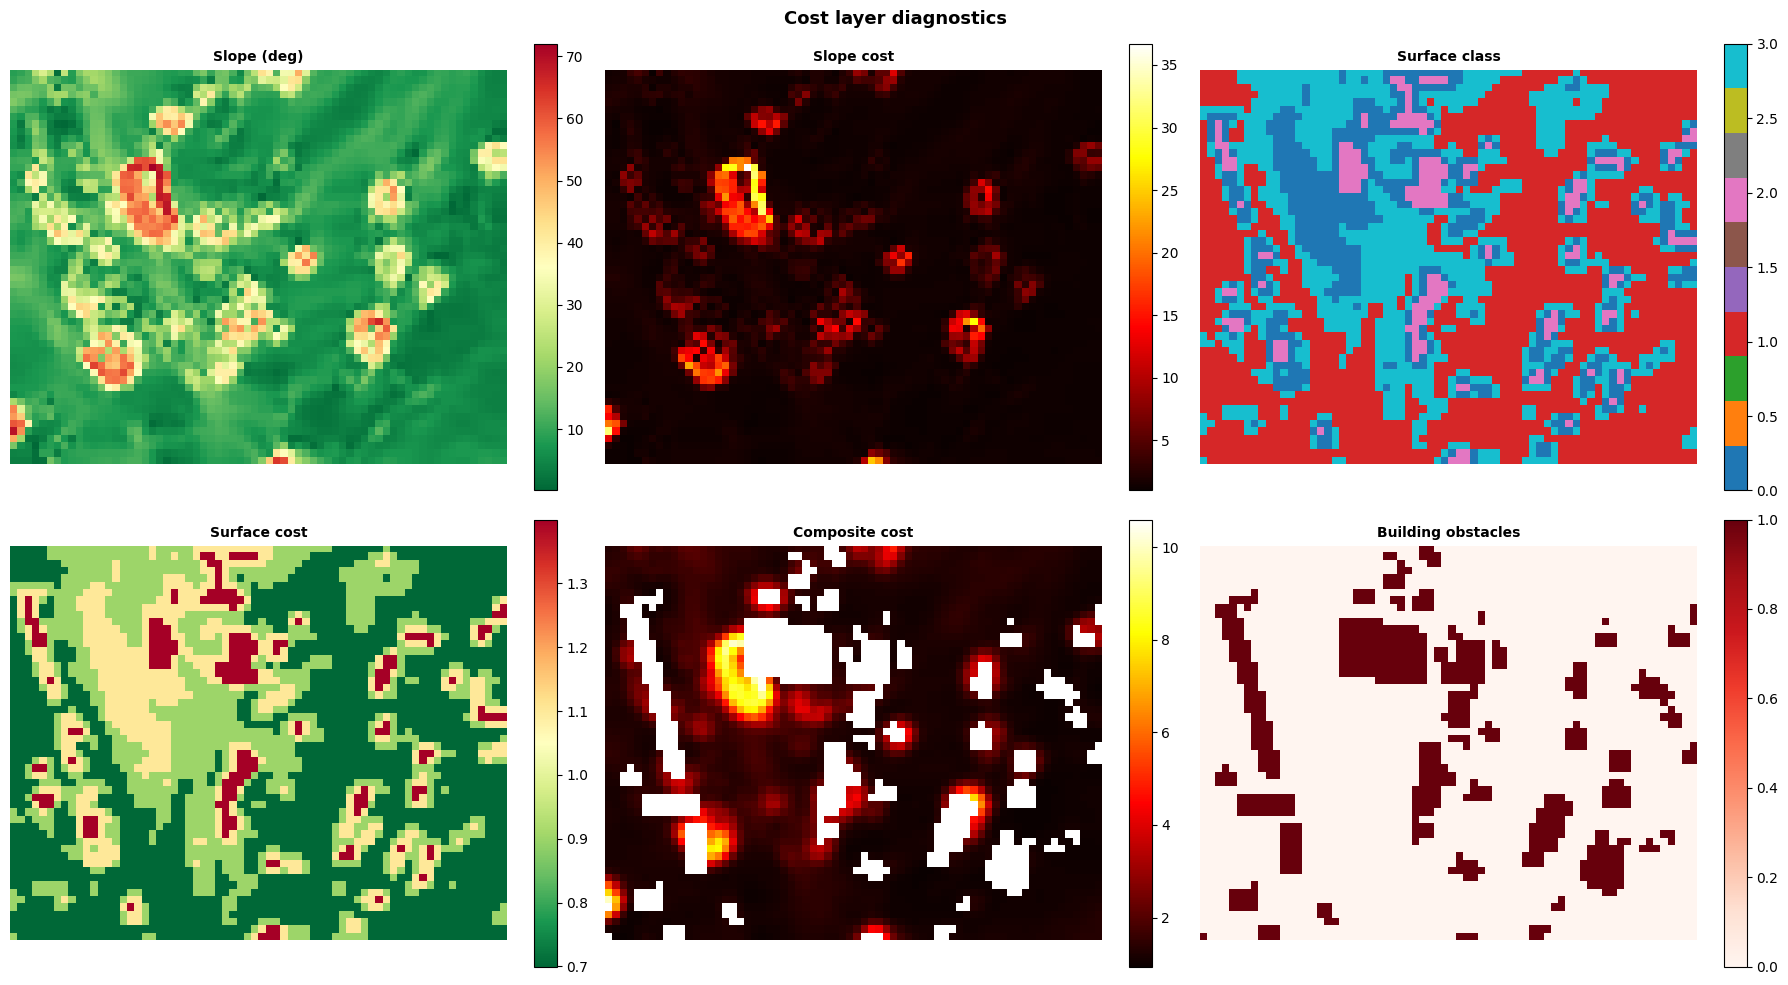

Saved output\diagnostics\cost_diagnostics.png


In [42]:
# Cost layer diagnostics
composite_diag = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=corridor_mult
)
obstacle_diag = data["bldg_raster"] | (~data["valid"])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
titles = [
    "Slope (deg)",
    "Slope cost",
    "Surface class",
    "Surface cost",
    "Composite cost",
    "Building obstacles",
]
layers = [
    slope_deg,
    slope_cost_grid,
    class_map,
    surface_cost_grid,
    composite_diag,
    obstacle_diag.astype(float),
]
cmaps = ["RdYlGn_r", "hot", "tab10", "RdYlGn_r", "hot", "Reds"]

for ax, layer, title, cmap in zip(axes.flat, layers, titles, cmaps):
    layer_disp = np.where(layer >= 1e5, np.nan, layer)
    im = ax.imshow(layer_disp, cmap=cmap, origin="upper")
    ax.set_title(title, fontsize=10, weight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_axis_off()

plt.suptitle("Cost layer diagnostics", fontsize=13, weight="bold")
plt.tight_layout()
output_dir = OUT / "diagnostics"
output_dir.mkdir(parents=True, exist_ok=True)
out_path = output_dir / "cost_diagnostics.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

In [ ]:
# Patch: make shapefile export robust to empty path sets.
def export_paths_shapefile(path_records, crs, filepath):
    if isinstance(path_records, gpd.GeoDataFrame):
        gdf = path_records.copy()
    elif not path_records:
        gdf = gpd.GeoDataFrame(
            {"geometry": gpd.GeoSeries([], crs=crs)},
            crs=crs,
        )
    else:
        gdf = gpd.GeoDataFrame(path_records)

    if "geometry" not in gdf.columns:
        gdf["geometry"] = gpd.GeoSeries([], crs=crs)

    gdf = gdf.set_geometry("geometry")
    if crs and gdf.crs is None:
        gdf.set_crs(crs, inplace=True)

    if gdf.empty:
        schema = {"geometry": "LineString", "properties": {}}
        for col in gdf.columns:
            if col == "geometry":
                continue
            dtype = gdf[col].dtype
            if dtype.kind in ("i", "u"):
                schema["properties"][col] = "int"
            elif dtype.kind == "f":
                schema["properties"][col] = "float"
            else:
                schema["properties"][col] = "str"
        gdf.to_file(filepath, driver="ESRI Shapefile", schema=schema, index=False)
    else:
        gdf.to_file(filepath, driver="ESRI Shapefile", index=False)

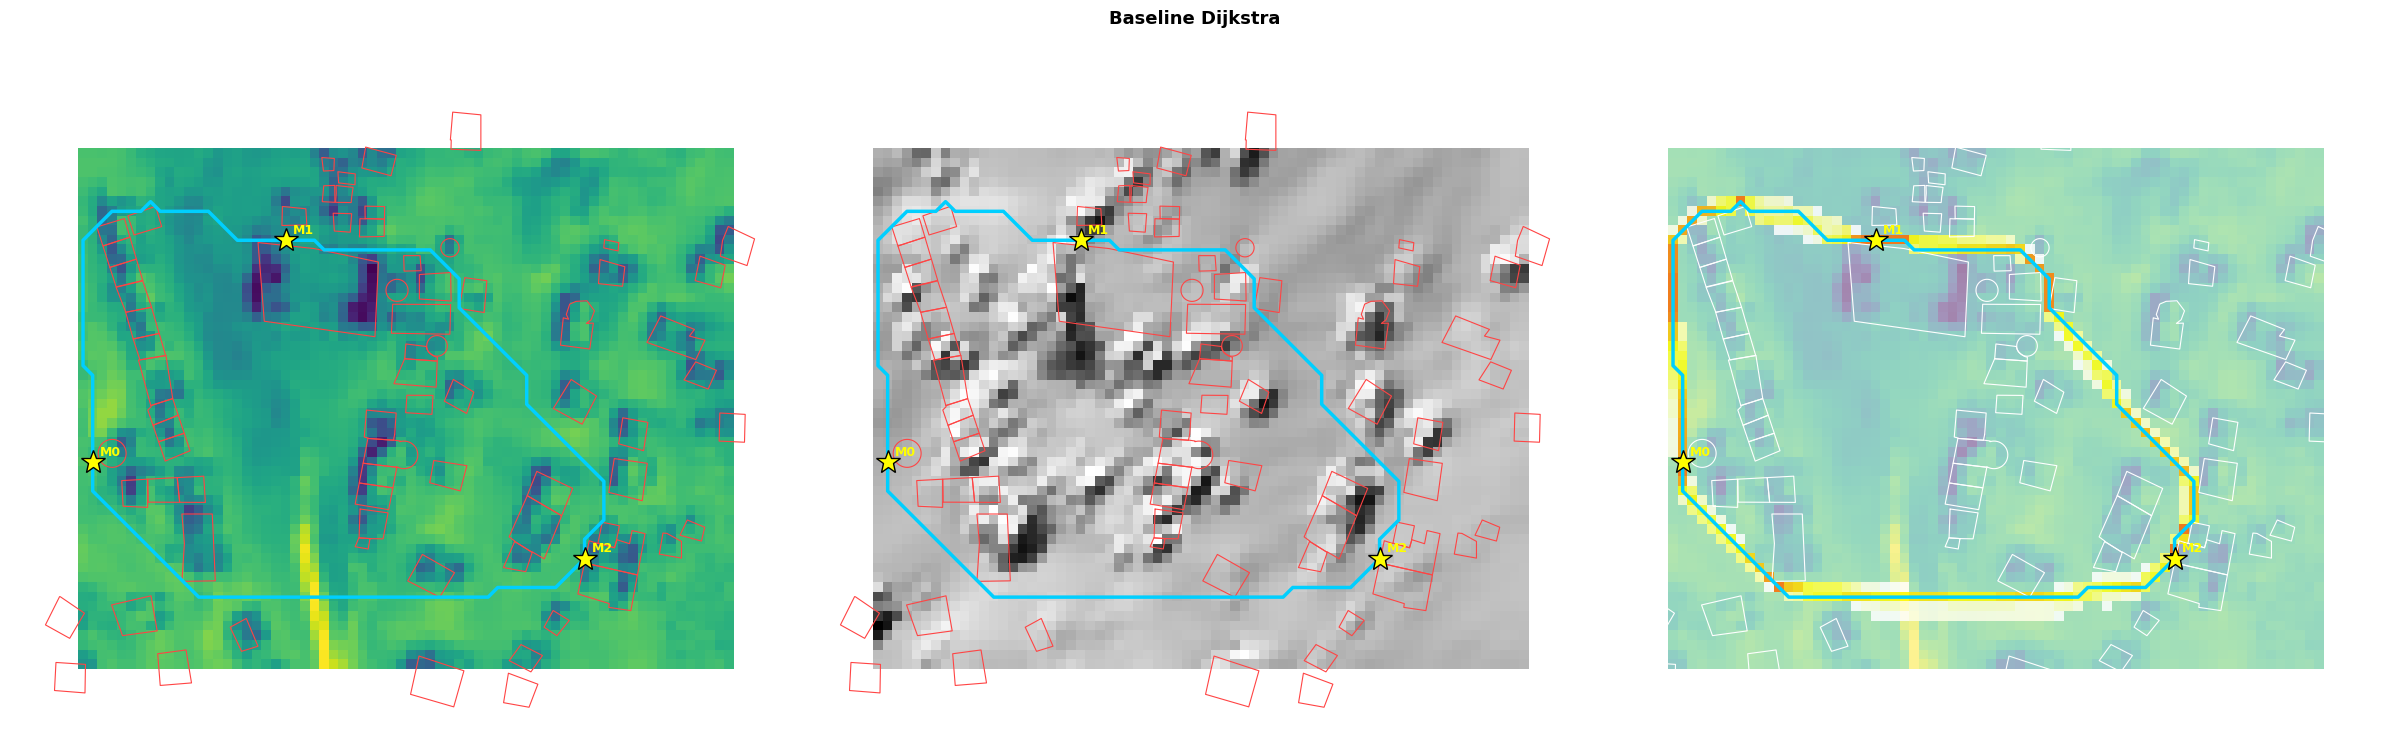

Completed Approach 1: Baseline Dijkstra.
 - Generated 3 paths.
 - Output saved to output\m1_dijkstra\m1_dijkstra_plot.png.
 - Vector layer saved to output\m1_dijkstra\m1_dijkstra_paths.shp.
 - Heatmap saved to output\m1_dijkstra\m1_dijkstra_heatmap.tif.



In [43]:
# Approach 1 - Baseline Dijkstra
composite = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=None
 )
mark_nodes = mark_nodes_from_marks(data, composite)
path_records, frequency_map, _ = run_dijkstra_mark_pairs(
    data, composite, mark_nodes, include_prob=True
 )
for rec in path_records:
    rec["method"] = "Dijkstra"

output_dir = OUT / "m1_dijkstra"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "Baseline Dijkstra",
    "m1_dijkstra/m1_dijkstra_plot.png",
    mark_nodes,
 )

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "m1_dijkstra_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "m1_dijkstra_heatmap.tif")

print("Completed Approach 1: Baseline Dijkstra.")
print(f" - Generated {len(path_records)} paths.")
print(f" - Output saved to {output_dir / 'm1_dijkstra_plot.png'}.")
print(f" - Vector layer saved to {output_dir / 'm1_dijkstra_paths.shp'}.")
print(f" - Heatmap saved to {output_dir / 'm1_dijkstra_heatmap.tif'}.\n")

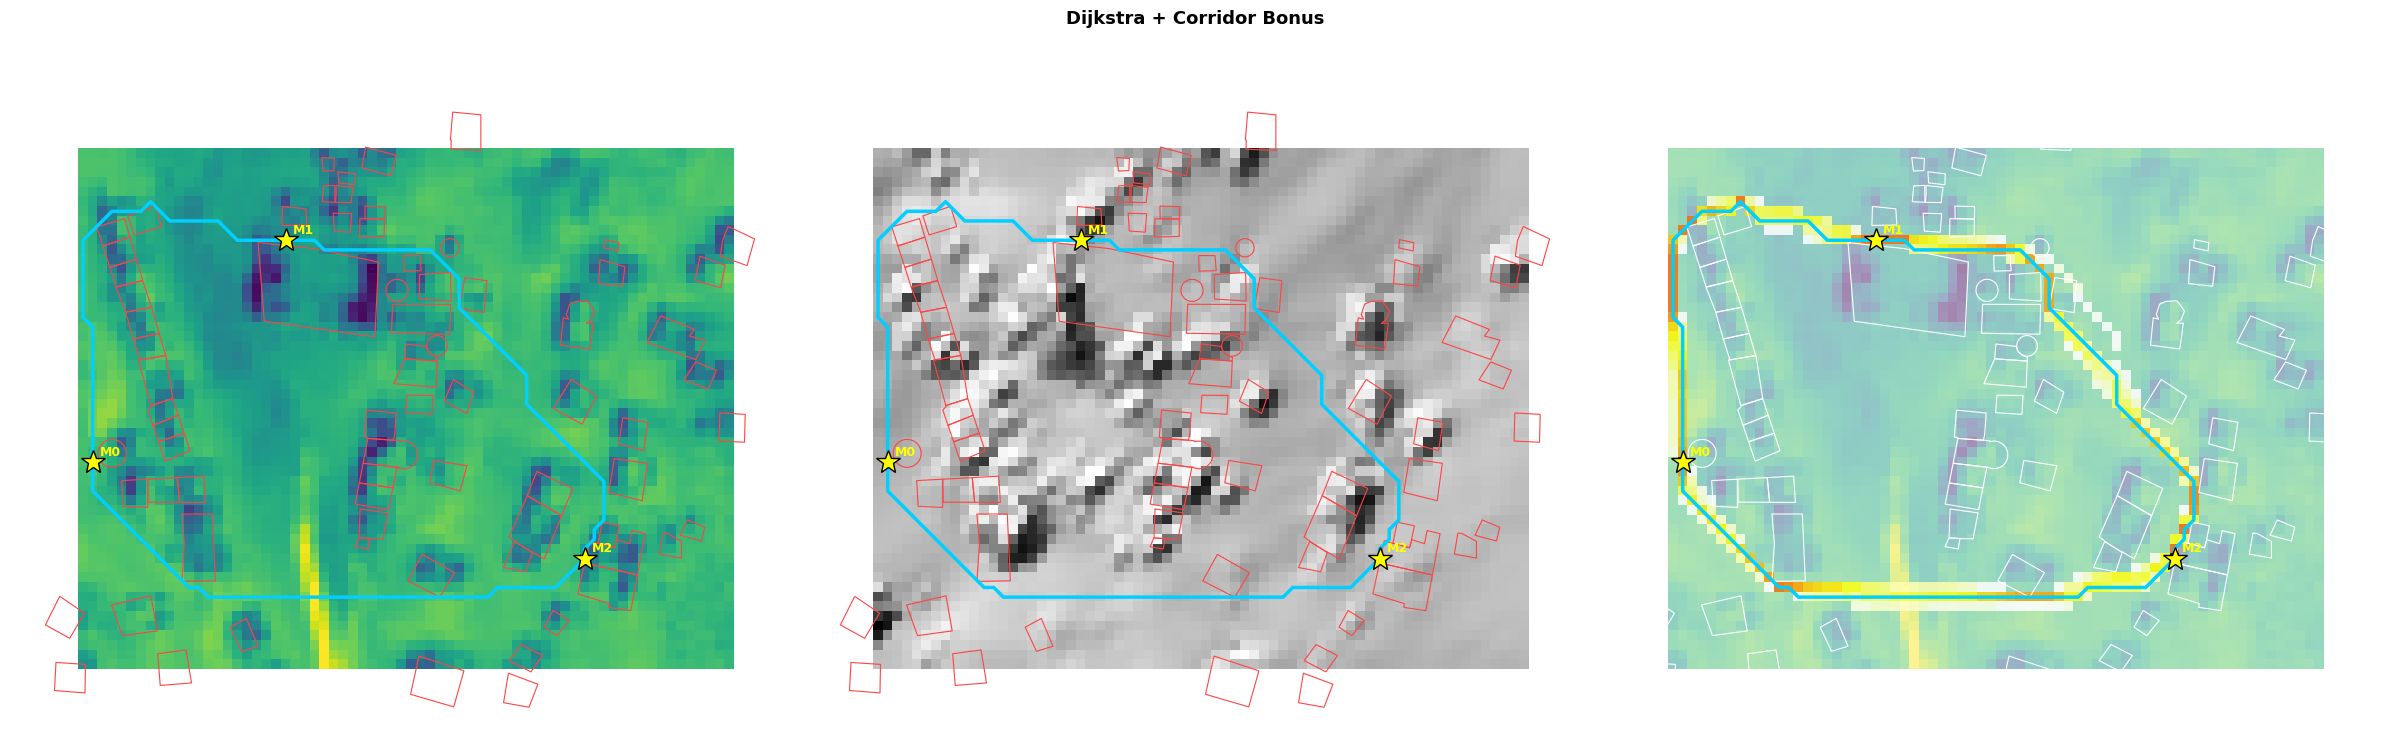

Completed Approach 2: Dijkstra + Corridor Bonus.
 - Generated 3 paths.
 - Output saved to output\m2_corridor\m2_corridor_plot.png.
 - Vector layer saved to output\m2_corridor\m2_corridor_paths.shp.
 - Heatmap saved to output\m2_corridor\m2_corridor_heatmap.tif.



In [44]:
# Approach 2 - Dijkstra + Corridor Bonus
composite = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=corridor_mult
 )
mark_nodes = mark_nodes_from_marks(data, composite)
path_records, frequency_map, _ = run_dijkstra_mark_pairs(
    data, composite, mark_nodes, include_prob=True
 )
for rec in path_records:
    rec["method"] = "Dijkstra+Corridor"

output_dir = OUT / "m2_corridor"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "Dijkstra + Corridor Bonus",
    "m2_corridor/m2_corridor_plot.png",
    mark_nodes,
 )

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "m2_corridor_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "m2_corridor_heatmap.tif")

print("Completed Approach 2: Dijkstra + Corridor Bonus.")
print(f" - Generated {len(path_records)} paths.")
print(f" - Output saved to {output_dir / 'm2_corridor_plot.png'}.")
print(f" - Vector layer saved to {output_dir / 'm2_corridor_paths.shp'}.")
print(f" - Heatmap saved to {output_dir / 'm2_corridor_heatmap.tif'}.\n")

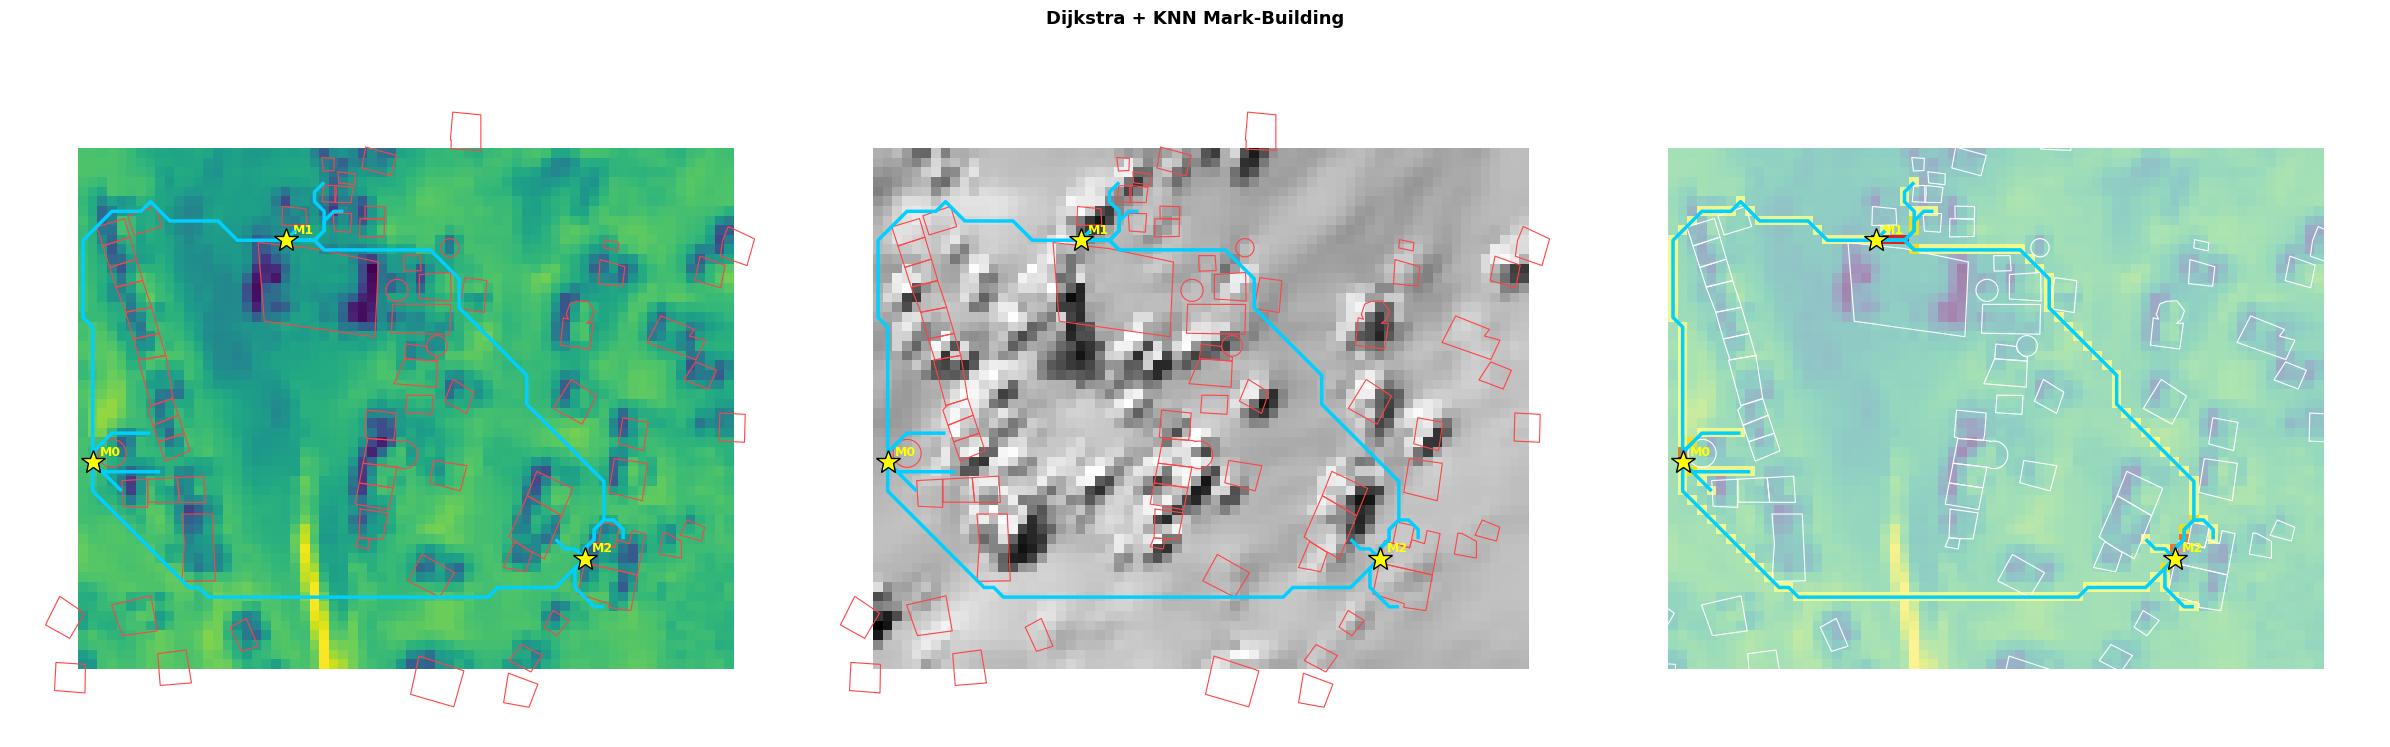

Completed Approach 3: Dijkstra + KNN Mark-Building.
 - Generated 15 paths.
 - Output saved to output\knn_mark_building\knn_mark_building_plot.png.
 - Vector layer saved to output\knn_mark_building\knn_mark_building_paths.shp.
 - Heatmap saved to output\knn_mark_building\knn_mark_building_heatmap.tif.



In [45]:
# Approach 3 - Dijkstra + Mark/Building Nodes + KNN
composite = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=corridor_mult
 )
mark_nodes = mark_nodes_from_marks(data, composite)
bldg_nodes = building_nodes(data, composite)
path_records, frequency_map, mark_rcs_list = run_dijkstra_mark_pairs(
    data, composite, mark_nodes, include_prob=False
 )
mark_rcs = np.array(mark_rcs_list)
bldg_rcs = np.array([n["rc"] for n in bldg_nodes])

if len(bldg_rcs) > 0:
    dists = np.sqrt(((mark_rcs[:, None, :] - bldg_rcs[None, :, :]) ** 2).sum(axis=2))
    knn_pairs = []
    for mi in range(len(mark_rcs)):
        nearest = np.argsort(dists[mi])[: CONFIG["K_NEAREST"]]
        for bi in nearest:
            knn_pairs.append(
                (mark_nodes[mi]["rc"], bldg_nodes[bi]["rc"], f"M{mi}", bldg_nodes[bi]["label"])
            )
else:
    knn_pairs = []

for src_rc, tgt_rc, src_lbl, tgt_lbl in knn_pairs:
    path, cost_val = dijkstra(composite, src_rc, tgt_rc)
    if path:
        coords = [rasterio.transform.xy(data["dem_tf"], r, c) for r, c in path]
        path_records.append(
            {"source": src_lbl, "target": tgt_lbl, "cost": float(cost_val), "geometry": LineString(coords)}
        )
        for r, c in path:
            frequency_map[r, c] += 1

for rec in path_records:
    rec["method"] = "KNN-Mark-Building"

output_dir = OUT / "knn_mark_building"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "Dijkstra + KNN Mark-Building",
    "knn_mark_building/knn_mark_building_plot.png",
    mark_nodes,
 )

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "knn_mark_building_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "knn_mark_building_heatmap.tif")

print("Completed Approach 3: Dijkstra + KNN Mark-Building.")
print(f" - Generated {len(path_records)} paths.")
print(f" - Output saved to {output_dir / 'knn_mark_building_plot.png'}.")
print(f" - Vector layer saved to {output_dir / 'knn_mark_building_paths.shp'}.")
print(f" - Heatmap saved to {output_dir / 'knn_mark_building_heatmap.tif'}.\n")

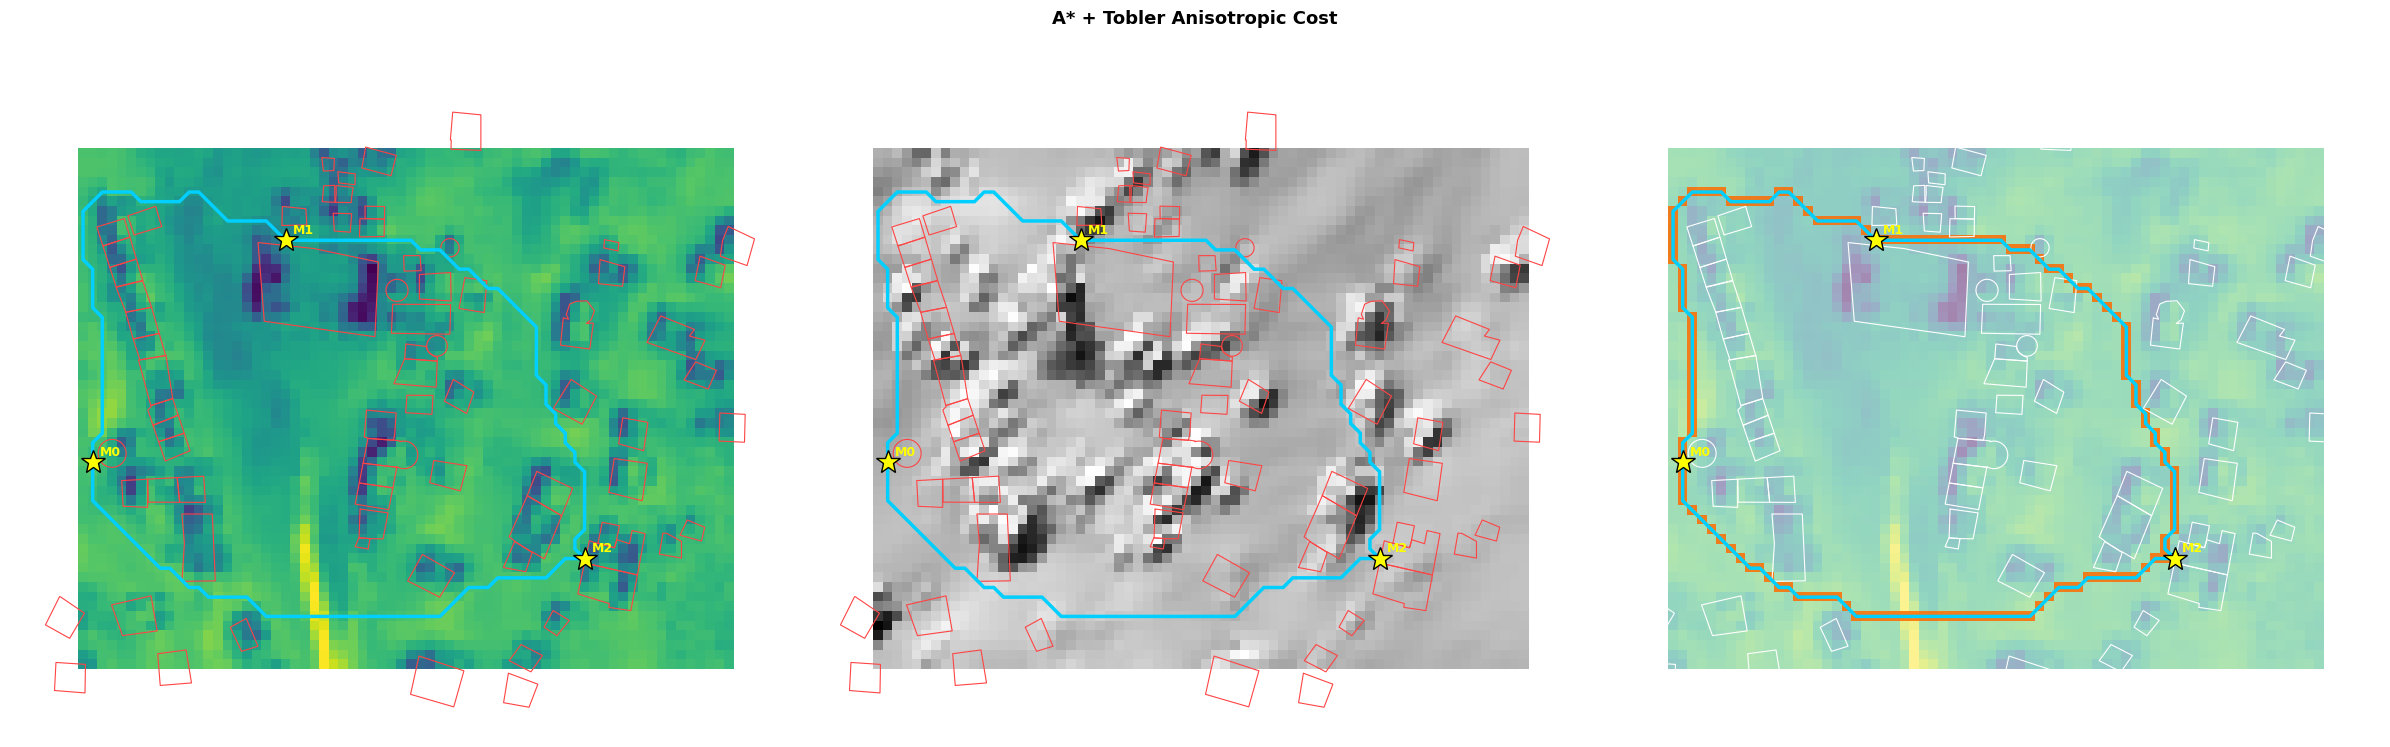

Completed Approach 4: A* + Tobler Anisotropic Cost.
 - Generated 3 paths.
 - Output saved to output\m4_astar_tobler\m4_astar_tobler_plot.png.
 - Vector layer saved to output\m4_astar_tobler\m4_astar_tobler_paths.shp.
 - Heatmap saved to output\m4_astar_tobler\m4_astar_tobler_heatmap.tif.



In [46]:
# Approach 4 - A* + Tobler Anisotropic Cost
corridor_mult = corridor_bonus(data["bldg_raster"])
obstacle = data["bldg_raster"] | (~data["valid"])
composite = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=corridor_mult
 )
mark_nodes = mark_nodes_from_marks(data, composite)
mark_rcs = [n["rc"] for n in mark_nodes]
pairs = [(i, j) for i in range(len(mark_rcs)) for j in range(i + 1, len(mark_rcs))]

path_records = []
frequency_map = np.zeros_like(data["dem"], dtype=np.float32)
for i, j in pairs:
    path, cost_val = astar_tobler(
        data["dem"],
        data["res_x"],
        data["res_y"],
        surface_cost_grid,
        corridor_mult,
        obstacle,
        mark_rcs[i],
        mark_rcs[j],
    )
    if not path:
        continue
    coords = [rasterio.transform.xy(data["dem_tf"], r, c) for r, c in path]
    path_records.append(
        {"source": f"M{i}", "target": f"M{j}", "cost": float(cost_val), "geometry": LineString(coords)}
    )
    for r, c in path:
        frequency_map[r, c] += 1

for rec in path_records:
    rec["method"] = "A*-Tobler"

output_dir = OUT / "m4_astar_tobler"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "A* + Tobler Anisotropic Cost",
    "m4_astar_tobler/m4_astar_tobler_plot.png",
    mark_nodes,
 )

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "m4_astar_tobler_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "m4_astar_tobler_heatmap.tif")

print("Completed Approach 4: A* + Tobler Anisotropic Cost.")
print(f" - Generated {len(path_records)} paths.")
print(f" - Output saved to {output_dir / 'm4_astar_tobler_plot.png'}.")
print(f" - Vector layer saved to {output_dir / 'm4_astar_tobler_paths.shp'}.")
print(f" - Heatmap saved to {output_dir / 'm4_astar_tobler_heatmap.tif'}.\n")

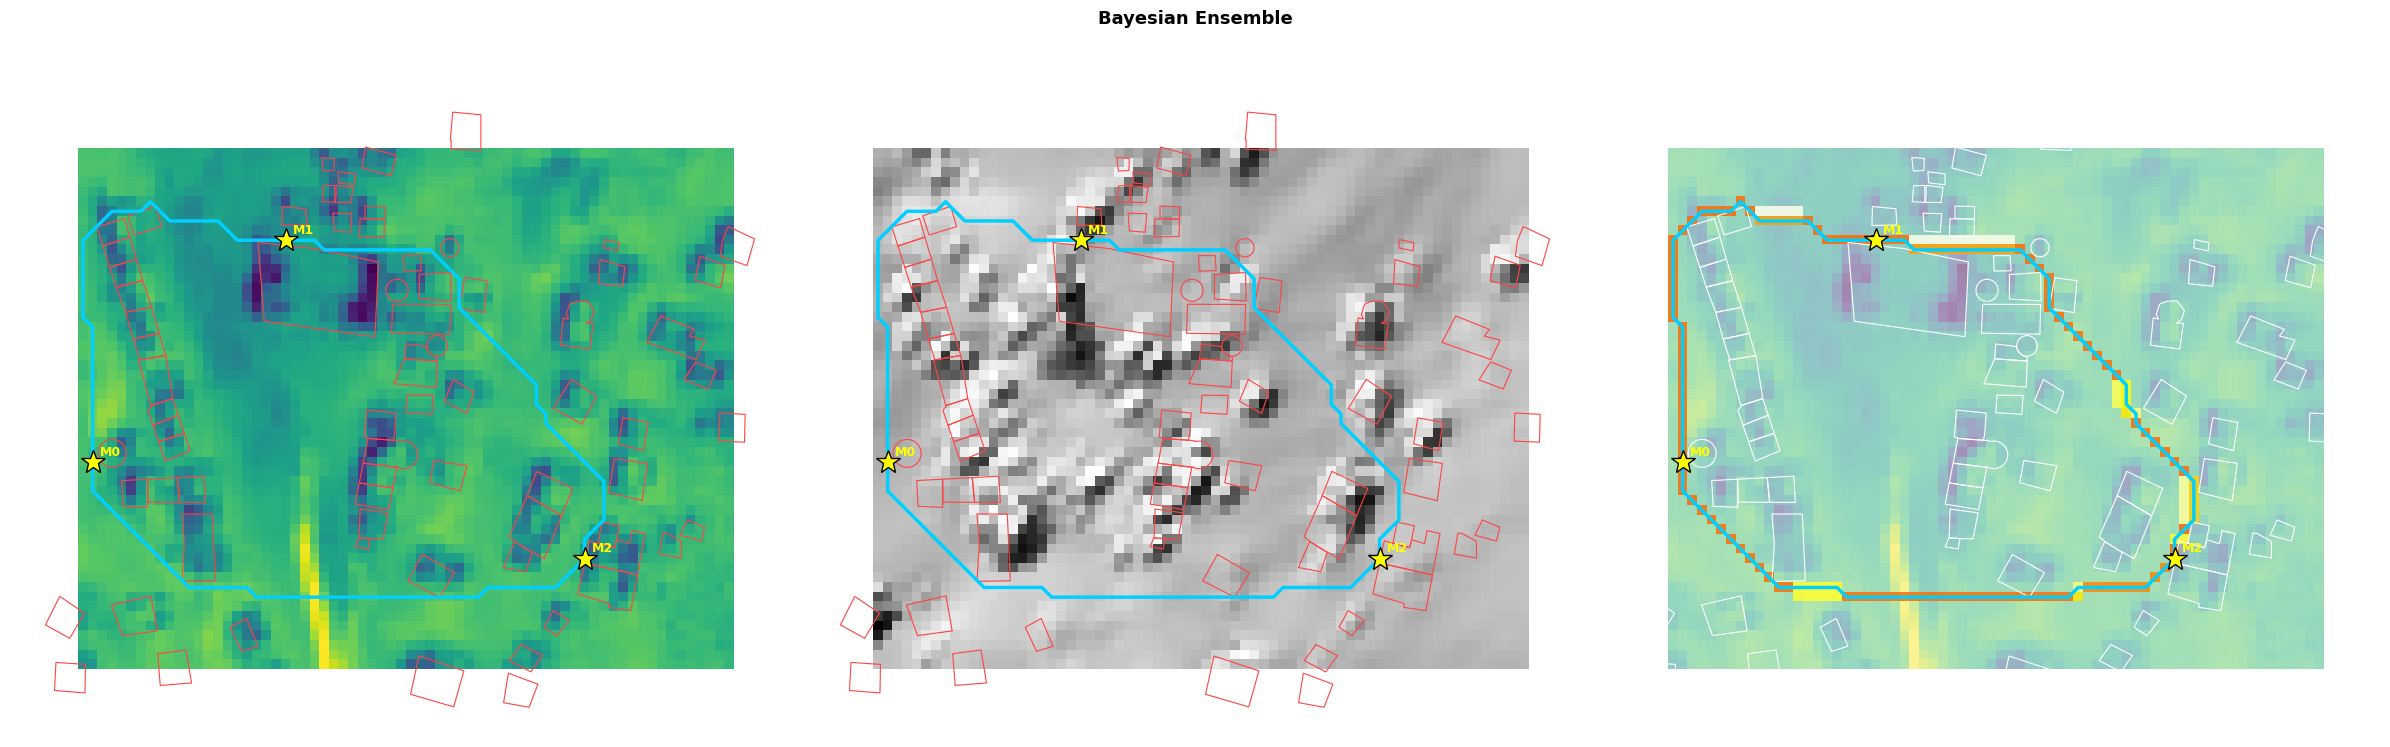

Completed Approach 5: Bayesian LCP Ensemble.
 - Generated 3 paths.
 - Output saved to output\m5_bayesian\m5_bayesian_plot.png.
 - Vector layer saved to output\m5_bayesian\m5_bayesian_paths.shp.
 - Heatmap saved to output\m5_bayesian\m5_bayesian_heatmap.tif.



In [47]:
# Approach 5 - Bayesian LCP Ensemble
dist_from_bldg = distance_transform_edt(~data["bldg_raster"]).astype(np.float32)
composite = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=corridor_mult
 )
mark_nodes = mark_nodes_from_marks(data, composite)
mark_rcs = [n["rc"] for n in mark_nodes]

frequency_map, best_paths, _combos, _post = bayesian_ensemble(
    data["dem"],
    slope_cost_grid,
    surface_cost_grid,
    data["bldg_raster"],
    data["valid"],
    dist_from_bldg,
    mark_rcs,
 )
path_records = []
pairs = [(i, j) for i in range(len(mark_rcs)) for j in range(i + 1, len(mark_rcs))]
for (i, j), path in zip(pairs, best_paths):
    if not path:
        continue
    coords = [rasterio.transform.xy(data["dem_tf"], r, c) for r, c in path]
    path_records.append({"source": f"M{i}", "target": f"M{j}", "geometry": LineString(coords)})

for rec in path_records:
    rec["method"] = "Bayesian Ensemble"

output_dir = OUT / "m5_bayesian"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "Bayesian Ensemble",
    "m5_bayesian/m5_bayesian_plot.png",
    mark_nodes,
 )

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "m5_bayesian_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "m5_bayesian_heatmap.tif")

print("Completed Approach 5: Bayesian LCP Ensemble.")
print(f" - Generated {len(path_records)} paths.")
print(f" - Output saved to {output_dir / 'm5_bayesian_plot.png'}.")
print(f" - Vector layer saved to {output_dir / 'm5_bayesian_paths.shp'}.")
print(f" - Heatmap saved to {output_dir / 'm5_bayesian_heatmap.tif'}.\n")

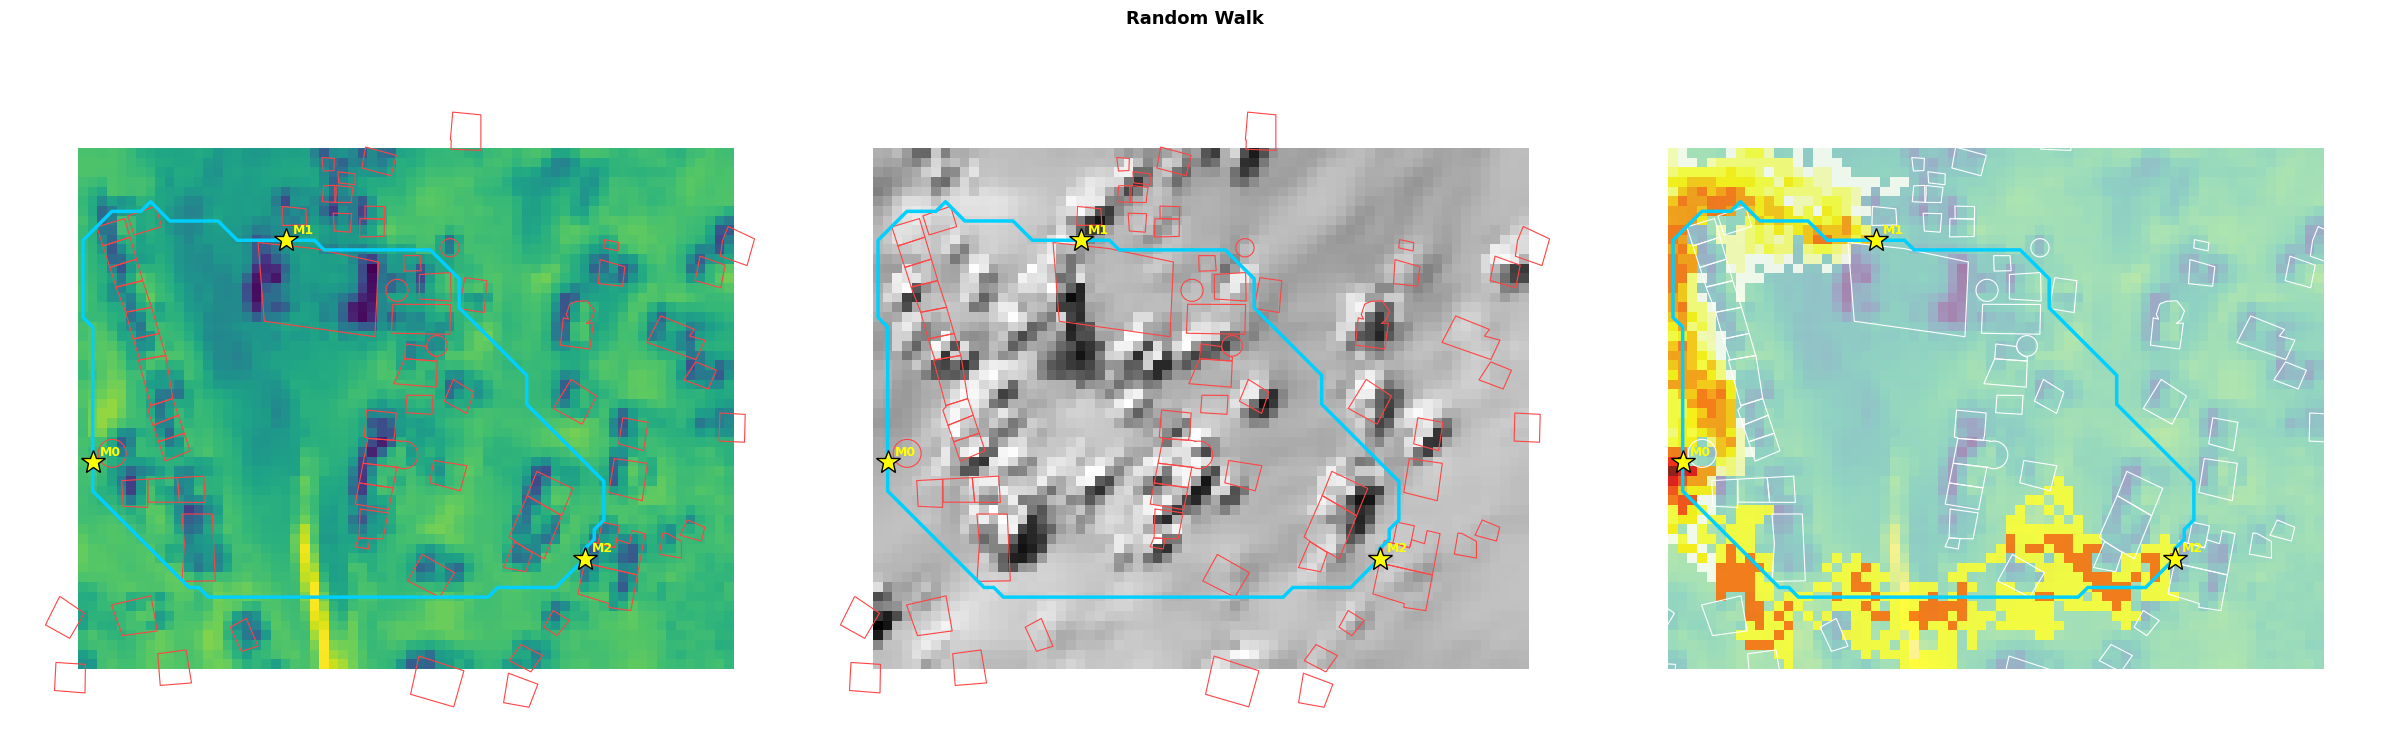

Completed Approach 6: Random Walk / Agent-Based Simulation.
 - Simulated random walks across the landscape.
 - Output saved to output\m6_random_walk\m6_random_walk_plot.png.
 - Vector layer saved to output\m6_random_walk\m6_random_walk_paths.shp.
 - Heatmap saved to output\m6_random_walk\m6_random_walk_heatmap.tif.



In [48]:
# Approach 6 - Random Walk / Agent-Based Simulation
composite = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=corridor_mult
)
obstacle = composite >= 1e5
mark_nodes = mark_nodes_from_marks(data, composite)
path_records, _ref_freq, mark_rcs = run_dijkstra_mark_pairs(
    data, composite, mark_nodes, include_prob=False
)
pairs = [(i, j) for i in range(len(mark_rcs)) for j in range(i + 1, len(mark_rcs))]

frequency_map = np.zeros_like(data["dem"], dtype=np.float32)
rng_agent = np.random.default_rng(7)

# Reduce runtime for notebook runs; increase these for higher-fidelity simulations.
rw_agents = min(CONFIG["RW_AGENTS"], 400)
rw_max_steps = min(CONFIG["RW_MAX_STEPS"], 800)
orig_agents = CONFIG["RW_AGENTS"]
orig_steps = CONFIG["RW_MAX_STEPS"]
CONFIG["RW_AGENTS"] = rw_agents
CONFIG["RW_MAX_STEPS"] = rw_max_steps
try:
    for i, j in pairs:
        freq, _ = random_walk_agents(mark_rcs[i], mark_rcs[j], composite, obstacle, rng_agent)
        frequency_map += freq
finally:
    CONFIG["RW_AGENTS"] = orig_agents
    CONFIG["RW_MAX_STEPS"] = orig_steps

for rec in path_records:
    rec["method"] = "Random Walk Ref"

output_dir = OUT / "m6_random_walk"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "Random Walk",
    "m6_random_walk/m6_random_walk_plot.png",
    mark_nodes,
)

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "m6_random_walk_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "m6_random_walk_heatmap.tif")

print("Completed Approach 6: Random Walk / Agent-Based Simulation.")
print(" - Simulated random walks across the landscape.")
print(f" - Output saved to {output_dir / 'm6_random_walk_plot.png'}.")
print(f" - Vector layer saved to {output_dir / 'm6_random_walk_paths.shp'}.")
print(f" - Heatmap saved to {output_dir / 'm6_random_walk_heatmap.tif'}.\n")

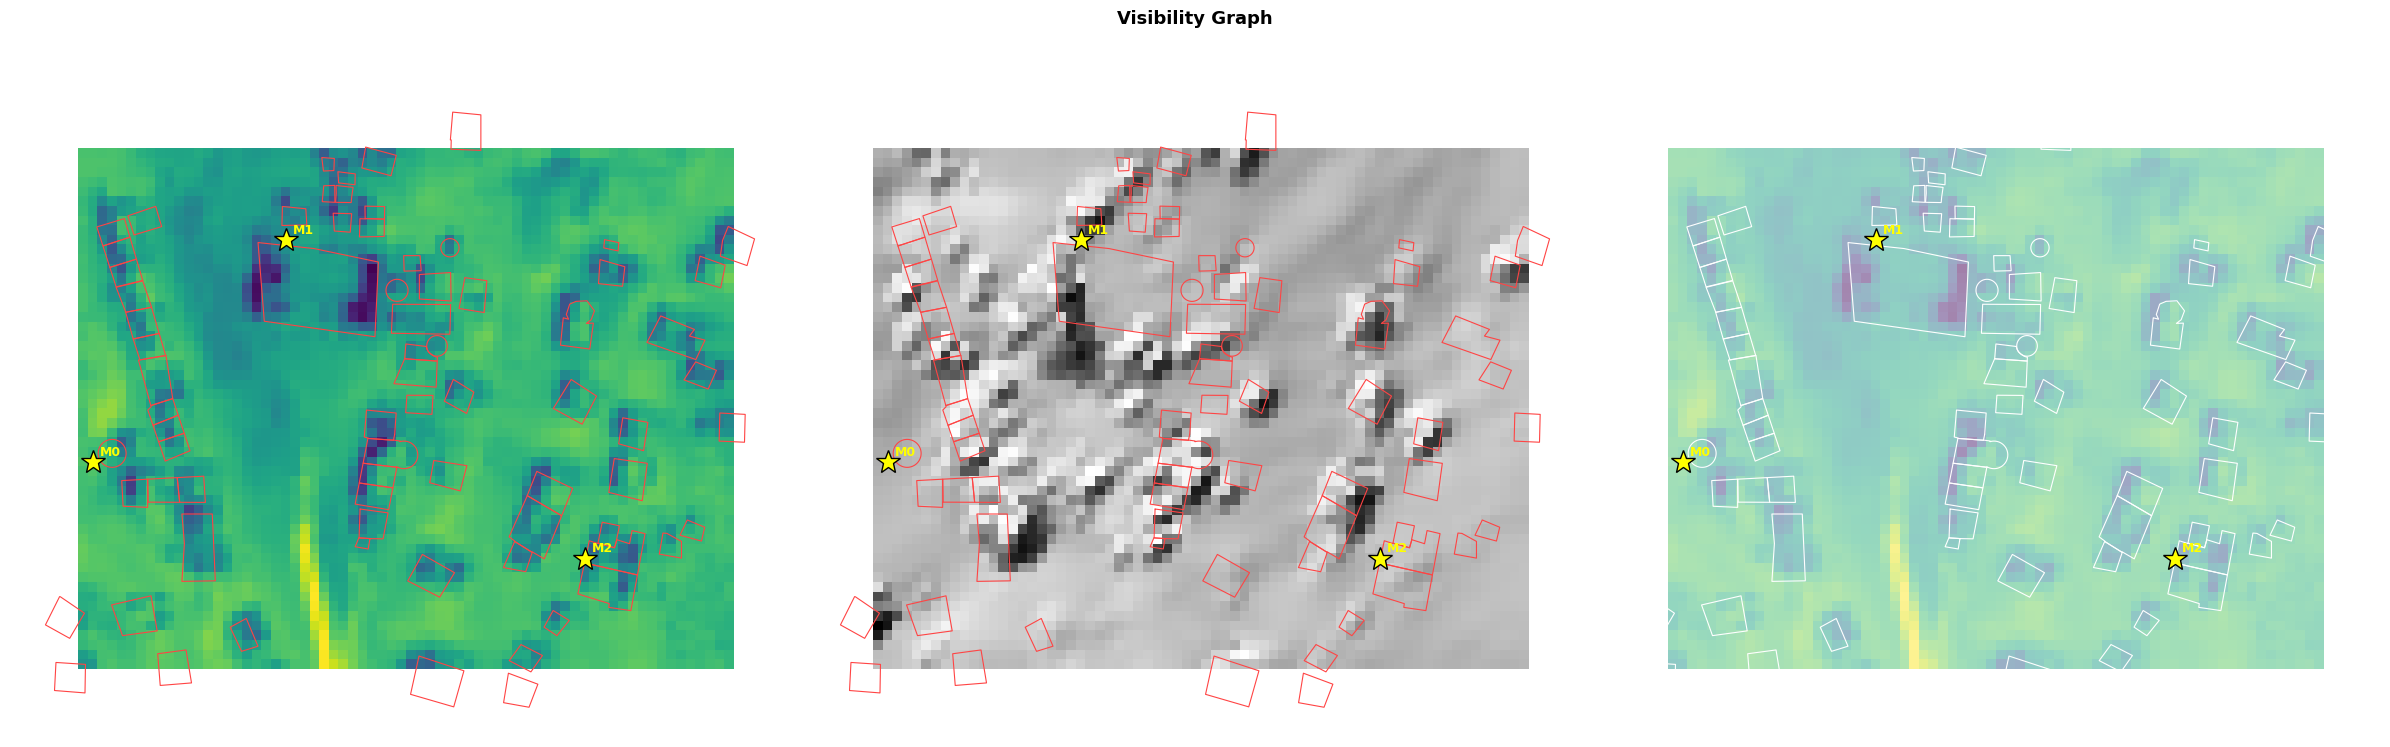

ValueError: Assigning CRS to a GeoDataFrame without a geometry column is not supported. Supply geometry using the 'geometry=' keyword argument, or by providing a DataFrame with column name 'geometry'

In [49]:
# Approach 7 - Visibility Graph + Shortest Path
composite = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=corridor_mult
 )
mark_nodes = mark_nodes_from_marks(data, composite)
waypoints, adj = visibility_graph(data["buildings"], data["dem_tf"], data["dem"], surface_cost_grid)

mark_pts = []
for _, row in data["marks"].iterrows():
    pt = row.geometry if row.geometry.geom_type == "Point" else list(row.geometry.geoms)[0]
    mark_pts.append(Point(pt.x, pt.y))
mark_indices = []
for mpt in mark_pts:
    best_i, best_d = 0, np.inf
    for i, wpt in enumerate(waypoints):
        d = mpt.distance(wpt)
        if d < best_d:
            best_d, best_i = d, i
    mark_indices.append(best_i)


def graph_dijkstra(adj, start_idx, end_idx):
    dist = {i: np.inf for i in range(len(waypoints))}
    prev = {}
    dist[start_idx] = 0.0
    pq = [(0.0, start_idx)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        if u == end_idx:
            break
        for v, w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))
    if dist[end_idx] == np.inf:
        return []
    path, cur = [], end_idx
    while cur != start_idx:
        path.append(cur)
        cur = prev[cur]
    path.append(start_idx)
    path.reverse()
    return path


pairs = [(i, j) for i in range(len(mark_indices)) for j in range(i + 1, len(mark_indices))]
path_records = []
frequency_map = np.zeros_like(data["dem"], dtype=np.float32)
for i, j in pairs:
    node_path = graph_dijkstra(adj, mark_indices[i], mark_indices[j])
    if not node_path:
        continue
    coords = [(waypoints[k].x, waypoints[k].y) for k in node_path]
    path_records.append({"source": f"M{i}", "target": f"M{j}", "geometry": LineString(coords)})

for rec in path_records:
    rec["method"] = "VisGraph"

output_dir = OUT / "m7_visibility_graph"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "Visibility Graph",
    "m7_visibility_graph/m7_visibility_graph_plot.png",
    mark_nodes,
 )

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "m7_visibility_graph_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "m7_visibility_graph_heatmap.tif")

print("Completed Approach 7: Visibility Graph + Shortest Path.")
print(f" - Generated {len(path_records)} paths.")
print(f" - Output saved to {output_dir / 'm7_visibility_graph_plot.png'}.")
print(f" - Vector layer saved to {output_dir / 'm7_visibility_graph_paths.shp'}.")
print(f" - Heatmap saved to {output_dir / 'm7_visibility_graph_heatmap.tif'}.\n")

In [ ]:
# Approach 8 - Entrance-Aware Routing
base_calc = slope_cost_grid + surface_cost_grid
directional_penalty = compute_directional_penalty(data, base_calc.shape, alpha=5.0)
composite = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=directional_penalty
 )
marks = mark_nodes_from_marks(data, composite)
path_records, frequency_map, _ = run_dijkstra_mark_pairs(
    data, composite, marks, include_prob=True
 )
for rec in path_records:
    rec["method"] = "Entrance-Aware"

output_dir = OUT / "m3_entrance_aware"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "Entrance-Aware Routing",
    "m3_entrance_aware/m3_entrance_aware_plot.png",
    marks,
 )

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "m3_entrance_aware_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "m3_entrance_aware_heatmap.tif")

print("Completed Approach 8: Entrance-Aware Routing.")
print(f" - Generated {len(path_records)} paths.")
print(f" - Output saved to {output_dir / 'm3_entrance_aware_plot.png'}.")
print(f" - Vector layer saved to {output_dir / 'm3_entrance_aware_paths.shp'}.")
print(f" - Heatmap saved to {output_dir / 'm3_entrance_aware_heatmap.tif'}.\n")

In [ ]:
# Approach 9 - PCA Spectral Anomaly Detection
gdf_paths = process_spectral_anomalies(data)

output_dir = OUT / "mA_spectral_anomaly"
output_dir.mkdir(parents=True, exist_ok=True)

export_paths_shapefile(gdf_paths, data["dem_crs"], output_dir / "mA_spectral_anomaly_paths.shp")

if gdf_paths.empty:
    print("No spectral anomaly paths detected.")
else:
    fig, ax = plt.subplots(figsize=(10, 10))
    ext = [
        data["dem_tf"][2],
        data["dem_tf"][2] + data["W"] * data["dem_tf"][0],
        data["dem_tf"][5] + data["H"] * data["dem_tf"][4],
        data["dem_tf"][5],
    ]
    with rasterio.open(DATA / "Orthoimage_Subset.tif") as src:
        show(src, ax=ax, alpha=0.6)
    data["buildings"].plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.5)
    gdf_paths.plot(ax=ax, color="#00FFCC", linewidth=2)
    ax.set_axis_off()
    plt.title("PCA Spectral Anomaly Paths", fontsize=16)
    plt.tight_layout()
    plt.savefig(output_dir / "mA_spectral_anomaly_plot.png", dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Exported {len(gdf_paths)} spectral anomaly path segments.")
    print(f" - Output saved to {output_dir / 'mA_spectral_anomaly_plot.png'}.\n")

In [ ]:
# Approach 10 - Structure Tensor Detection
gdf_paths = process_structural_tensor(data)

output_dir = OUT / "mB_structure_tensor"
output_dir.mkdir(parents=True, exist_ok=True)

export_paths_shapefile(gdf_paths, data["dem_crs"], output_dir / "mB_structure_tensor_paths.shp")

if gdf_paths.empty:
    print("No structure tensor paths detected.")
else:
    fig, ax = plt.subplots(figsize=(10, 10))
    ext = [
        data["dem_tf"][2],
        data["dem_tf"][2] + data["W"] * data["dem_tf"][0],
        data["dem_tf"][5] + data["H"] * data["dem_tf"][4],
        data["dem_tf"][5],
    ]
    with rasterio.open(DATA / "Orthoimage_Subset.tif") as src:
        show(src, ax=ax, alpha=0.6)
    data["buildings"].plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.5)
    gdf_paths.plot(ax=ax, color="#FF00FF", linewidth=2)
    ax.set_axis_off()
    plt.title("Structure Tensor Detected Paths", fontsize=16)
    plt.tight_layout()
    plt.savefig(output_dir / "mB_structure_tensor_plot.png", dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Exported {len(gdf_paths)} structure tensor path segments.")
    print(f" - Output saved to {output_dir / 'mB_structure_tensor_plot.png'}.\n")

In [ ]:
# Approach 11 - MaxEnt IRL Learned Cost
proxy_comp = composite_cost(
    slope_cost_grid, surface_cost_grid, data["bldg_raster"], data["valid"], corridor_mult=corridor_mult
 )
expert_paths = get_expert_paths(data, proxy_comp)

feature_map_raw = np.stack(
    [slope_deg, surface_cost_grid, corridor_mult, data["dem"]], axis=-1
 )
moves = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

learned_theta = maxent_irl(feature_map_raw, data["valid"], expert_paths, moves, n_iter=10)

H, W, n_feat = feature_map_raw.shape
feature_map = np.zeros_like(feature_map_raw)
for f in range(n_feat):
    valid_feats = feature_map_raw[:, :, f][data["valid"]]
    mu, std = np.mean(valid_feats), np.std(valid_feats) + 1e-8
    feature_map[:, :, f] = (feature_map_raw[:, :, f] - mu) / std
    feature_map[~data["valid"], f] = 0

reward_grid = np.dot(feature_map, learned_theta)
irl_cost = np.exp(-reward_grid).astype(np.float32)
irl_cost[data["bldg_raster"]] = 1e6
irl_cost[~data["valid"]] = 1e6

marks = mark_nodes_from_marks(data, irl_cost)
path_records, frequency_map, _ = run_dijkstra_mark_pairs(
    data, irl_cost, marks, include_prob=True
 )
for rec in path_records:
    rec["method"] = "MaxEnt-IRL"

output_dir = OUT / "mC_irl_learned"
output_dir.mkdir(parents=True, exist_ok=True)

plot_paths(
    data,
    path_records,
    frequency_map,
    "MaxEnt IRL Learned Paths",
    "mC_irl_learned/mC_irl_learned_plot.png",
    marks,
 )

export_paths_shapefile(path_records, data["dem_crs"], output_dir / "mC_irl_learned_paths.shp")
export_heatmap_geotiff(frequency_map, data["dem_meta"], output_dir / "mC_irl_learned_heatmap.tif")

print("Completed Approach 11: MaxEnt IRL Learned Cost.")
print(f" - Generated {len(path_records)} paths.")
print(f" - Output saved to {output_dir / 'mC_irl_learned_plot.png'}.\n")

In [ ]:
# Consensus Visualization
heatmaps = [
    OUT / "m1_dijkstra" / "m1_dijkstra_heatmap.tif",
    OUT / "m2_corridor" / "m2_corridor_heatmap.tif",
    OUT / "m3_entrance_aware" / "m3_entrance_aware_heatmap.tif",
    OUT / "m4_astar_tobler" / "m4_astar_tobler_heatmap.tif",
    OUT / "mC_irl_learned" / "mC_irl_learned_heatmap.tif",
]

consensus_map = np.zeros_like(data["dem"], dtype=np.float32)
methods_loaded = 0

for hm_path in heatmaps:
    if hm_path.exists():
        with rasterio.open(hm_path) as src:
            hm_data = src.read(1)
            if hm_data.max() > 0:
                hm_data = hm_data / hm_data.max()
            vote = (hm_data > 0.05).astype(np.float32)
            consensus_map += vote
            methods_loaded += 1

if methods_loaded == 0:
    print("No heatmaps found to build consensus. Run the routing methods first.")
else:
    output_dir = OUT / "consensus"
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(14, 14))
    ext = [
        data["dem_tf"][2],
        data["dem_tf"][2] + data["W"] * data["dem_tf"][0],
        data["dem_tf"][5] + data["H"] * data["dem_tf"][4],
        data["dem_tf"][5],
    ]

    with rasterio.open(DATA / "Orthoimage_Subset.tif") as src:
        show(src, ax=ax, alpha=0.6)

    data["buildings"].plot(ax=ax, facecolor="none", edgecolor="white", linewidth=1.5, zorder=5)

    cmap = plt.cm.plasma
    cmap.set_under(alpha=0)
    im = ax.imshow(
        consensus_map,
        cmap=cmap,
        alpha=0.8,
        vmin=1.5,
        vmax=methods_loaded,
        origin="upper",
        extent=ext,
        zorder=3,
    )

    cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
    cbar.set_label("Number of Intersecting Path Models", rotation=270, labelpad=15)

    cv_paths = [
        (OUT / "mA_spectral_anomaly" / "mA_spectral_anomaly_paths.shp", "#00FFCC", "PCA Spectral Anomaly"),
        (OUT / "mB_structure_tensor" / "mB_structure_tensor_paths.shp", "#FF00FF", "Structure Tensor"),
    ]
    for shp_path, color, label in cv_paths:
        if shp_path.exists():
            gdf = gpd.read_file(shp_path)
            if not gdf.empty:
                gdf.plot(ax=ax, color=color, linewidth=2.5, label=label, zorder=6)

    dummy_cost = np.ones_like(data["dem"])
    marks = mark_nodes_from_marks(data, dummy_cost)
    for n in marks:
        xy = rasterio.transform.xy(data["dem_tf"], n["rc"][0], n["rc"][1])
        ax.plot(*xy, "*", color="yellow", markersize=14, markeredgecolor="black", zorder=7)

    ax.set_axis_off()
    plt.title("El Bagawat: Pre-Submission Demo Method Consensus", fontsize=18, weight="bold")

    custom_lines = [
        Line2D([0], [0], color="#00FFCC", lw=3),
        Line2D([0], [0], color="#FF00FF", lw=3),
    ]
    ax.legend(custom_lines, [l for _, _, l in cv_paths], loc="upper right", framealpha=0.9)

    plt.tight_layout()
    plt.savefig(output_dir / "final_consensus_map.png", dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("Exported final_consensus_map.png")

In [ ]:
# Output Cross-Check
expected = {
    "m1_dijkstra": "m1_dijkstra_paths",
    "m2_corridor": "m2_corridor_paths",
    "m3_entrance_aware": "m3_entrance_aware_paths",
    "m4_astar_tobler": "m4_astar_tobler_paths",
    "m5_bayesian": "m5_bayesian_paths",
    "m6_random_walk": "m6_random_walk_paths",
    "m7_visibility_graph": "m7_visibility_graph_paths",
    "mA_spectral_anomaly": "mA_spectral_anomaly_paths",
    "mB_structure_tensor": "mB_structure_tensor_paths",
    "mC_irl_learned": "mC_irl_learned_paths",
    "knn_mark_building": "knn_mark_building_paths",
}
extensions = [".shp", ".shx", ".dbf", ".prj", ".cpg"]
missing = []

for folder, base_name in expected.items():
    for ext in extensions:
        path = OUT / folder / f"{base_name}{ext}"
        if not path.exists():
            missing.append(path)

if missing:
    print("Missing outputs:")
    for path in missing:
        print(f" - {path}")
else:
    print("All expected shapefile components are present.")

## Approach Summary Grid

| Approach | Method | Novel Contribution |
| --- | --- | --- |
| 1. Baseline Dijkstra | Composite cost (slope+surface), 8-connected grid | Multi-variable vs. slope-only LCP |
| 2. Corridor Bonus | Distance-transform building proximity reward | Corridor geometry encoding |
| 3. KNN Routing | Building centroids as intermediate nodes | Architectural logic in routing |
| 4. A* + Tobler | Anisotropic hiking function, admissible heuristic | Directional slope asymmetry |
| 5. Bayesian Ensemble | Weight-sweep over (W_slope, W_surface) grid | Uncertainty over cost parameters |
| 6. Agent Random Walk | 3,000 goal-biased agents per mark pair | Stochastic path distribution |
| 7. Visibility Graph | Building corner waypoints, geometric routing | Obstacle-aware geometric paths |

C:\Users\manan\AppData\Local\Temp\ipykernel_24968\413004166.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


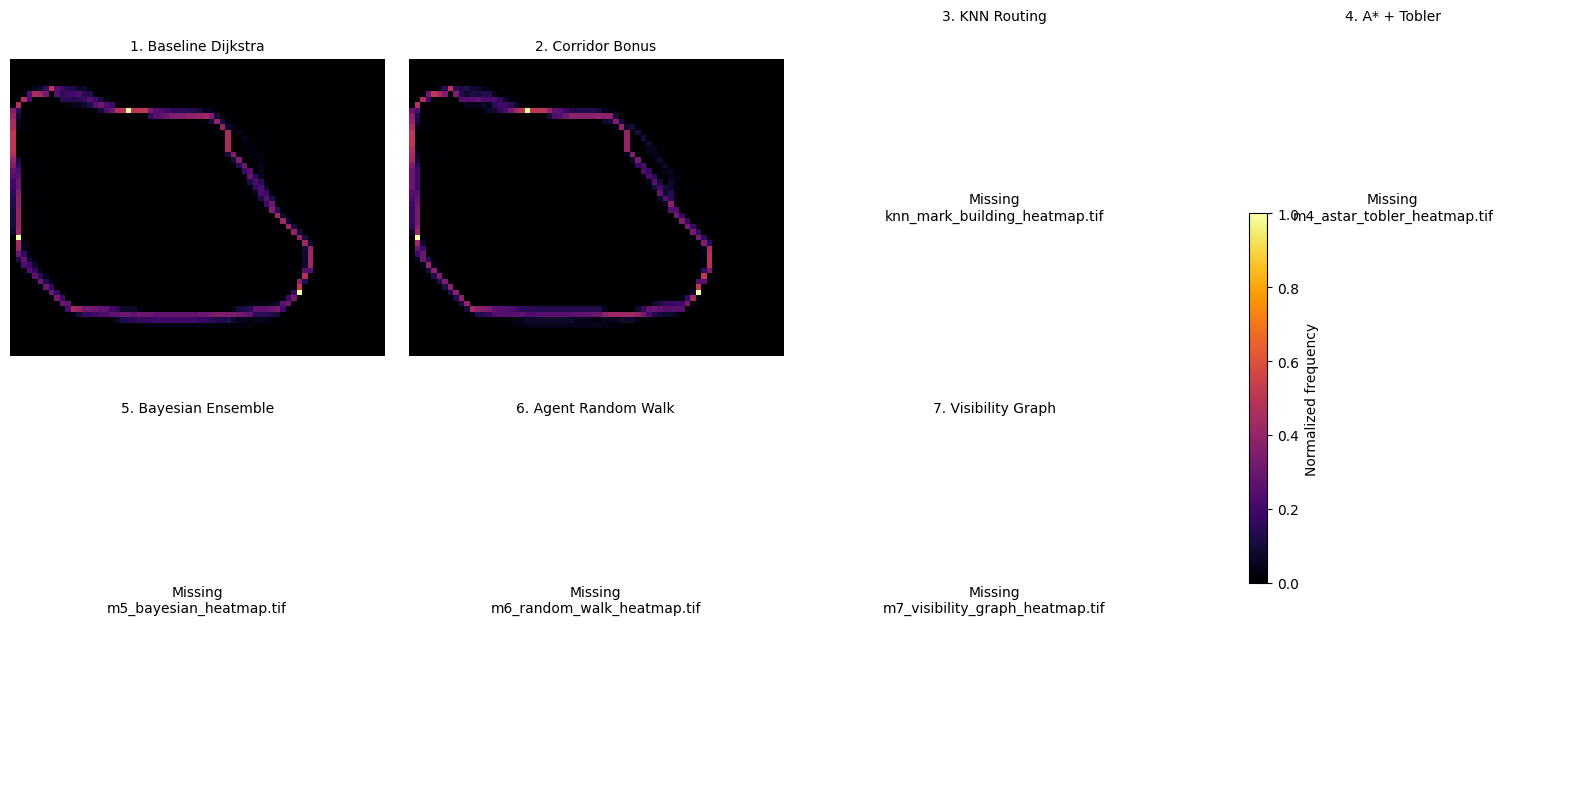

Saved heatmap grid to ..\output\comparison\heatmap_grid.png


In [ ]:
# Heatmap Comparison Grid
import math

heatmaps = [
    ("1. Baseline Dijkstra", OUT / "m1_dijkstra" / "m1_dijkstra_heatmap.tif"),
    ("2. Corridor Bonus", OUT / "m2_corridor" / "m2_corridor_heatmap.tif"),
    ("3. KNN Routing", OUT / "knn_mark_building" / "knn_mark_building_heatmap.tif"),
    ("4. A* + Tobler", OUT / "m4_astar_tobler" / "m4_astar_tobler_heatmap.tif"),
    ("5. Bayesian Ensemble", OUT / "m5_bayesian" / "m5_bayesian_heatmap.tif"),
    ("6. Agent Random Walk", OUT / "m6_random_walk" / "m6_random_walk_heatmap.tif"),
    ("7. Visibility Graph", OUT / "m7_visibility_graph" / "m7_visibility_graph_heatmap.tif"),
]

cols = 4
rows = math.ceil(len(heatmaps) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_1d(axes).ravel()

ext = [
    data["dem_tf"][2],
    data["dem_tf"][2] + data["W"] * data["dem_tf"][0],
    data["dem_tf"][5] + data["H"] * data["dem_tf"][4],
    data["dem_tf"][5],
]

last_im = None
for ax, (label, path) in zip(axes, heatmaps):
    if path.exists():
        with rasterio.open(path) as src:
            hm = src.read(1)
        if hm.max() > 0:
            # Normalize each heatmap for pattern comparison.
            hm = hm / hm.max()
        last_im = ax.imshow(
            hm, cmap="inferno", vmin=0.0, vmax=1.0, origin="upper", extent=ext
        )
    else:
        ax.text(0.5, 0.5, f"Missing\n{path.name}", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(label, fontsize=10)
    ax.set_axis_off()

for ax in axes[len(heatmaps):]:
    ax.set_axis_off()

if last_im is not None:
    fig.colorbar(last_im, ax=axes.tolist(), shrink=0.6, pad=0.02, label="Normalized frequency")

output_dir = OUT / "comparison"
output_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(output_dir / "heatmap_grid.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved heatmap grid to {output_dir / 'heatmap_grid.png'}")